# 🚗 Driver Wellness AI
## End-to-End Integrated Driver Monitoring System

### Milestone 4 – Final Integrated Notebook

---

## Team Members

| Module | Team Member |
|---------|-------------|
| 🎥 Video-Based Fatigue Detection | Kushagra Barodekar |
| 😊 Landmark-Based Fatigue Detection | Shiwani |
| 🚘 Driver Activity Recognition | Shubham |
| 📱 Seat Belt Detection | Sohini |
| 🚬 Smoking & Drinking Detection | Ravina |

---

## Project Overview

Driver Wellness AI combines multiple independently trained deep learning models into a single
integrated **Driver Wellness pipeline**. Each model analyzes the same input video independently
and produces a standardized prediction. A central **Risk Fusion Engine** combines every module's
output into one overall **Driver Wellness Score**.

This notebook is the **production integration layer**. It does **not** redesign, retrain, or
reimplement any model. Every adapter below wraps the *existing* inference logic documented in the
per-module Technical Integration Specifications / Module Manager Contracts, exactly as trained.

## System Pipeline

```
                         Input Driving Video
                                  │
                                  ▼
             ┌────────────────────────────────────────────┐
             │              AI Detection Modules           │
             ├────────────────────────────────────────────┤
             │  🎥 Video Fatigue Detection                 │
             │  😊 Landmark Fatigue Detection              │
             │  🚘 Driver Activity Recognition             │
             │  🚬 Smoking & Drinking Detection             │
             │  📱 Seat Belt Detection                     │
             └────────────────────────────────────────────┘
                                  │
                                  ▼
                         Risk Fusion Engine
                                  │
                                  ▼
                     Driver Wellness Score (0-100)
                                  │
                                  ▼
                        Dashboard / Report
```

## Notebook Structure

1. Install Dependencies
2. Mount Google Drive
3. Configuration
4. Model Registry
5. Upload Video
6. Core SDK (`PredictionResult`, `InferenceContext`, `BaseModelAdapter`, `AdapterRegistry`, `DriverWellnessModuleManager`)
7. Video Fatigue Adapter
8. Driver Activity Adapter
9. Landmark Adapter
10. Smoking Adapter
11. Seatbelt Adapter
12. `DriverWellnessModuleManager` — register & wire up every adapter
13. Risk Fusion Engine
14. Dashboard
15. End-to-End Demo

---

**Streaming mode (default):** single-pass video decode, bounded temporal buffers, and continuous risk fusion — satisfies the TA sliding-window simulation requirement.


## 1. Install Dependencies

Colab already ships `torch`, `torchvision`, `opencv-python`, `numpy`, `Pillow`, `pandas`, and
`matplotlib`. Only `ultralytics` (Smoking & Drinking / Seatbelt YOLO adapters) and `mediapipe`
(Landmark Fatigue adapter) need to be installed explicitly.

In [25]:
# ==========================================================
# Driver Wellness AI — Dependency Installation
# ==========================================================
# Ultralytics -> Smoking/Drinking + Seatbelt YOLO adapters (Sections 10-11)
# MediaPipe   -> Landmark Fatigue adapter, face landmark extraction (Section 9)
%pip -q install "ultralytics>=8.3.0" "mediapipe>=0.10.14" psutil >/dev/null 2>&1

print("=" * 80)
print("Dependency installation complete")
print("=" * 80)

import ultralytics
import mediapipe

print(f"ultralytics : {ultralytics.__version__}")
print(f"mediapipe   : {mediapipe.__version__}")

Dependency installation complete
ultralytics : 8.4.115
mediapipe   : 1.0.0


## 2. Mount Google Drive

All model checkpoints live under `MODEL_ROOT` on Google Drive (see Section 3 for the exact path).

In [26]:
# ==========================================================
# Mount Google Drive
# ==========================================================
from google.colab import drive

drive.mount("/content/drive")

print("=" * 80)
print("Google Drive mounted at /content/drive")
print("=" * 80)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted at /content/drive


## 3. Configuration

Every numeric constant below is taken directly from the per-module Technical Integration
Specifications / Module Manager Contracts (source of truth) — nothing here is invented.

In [27]:
# ==========================================================
# Driver Wellness AI — Configuration
# ==========================================================
from pathlib import Path

import torch

# ----------------------------------------------------------
# Paths
# ----------------------------------------------------------
DRIVE_ROOT = Path("/content/models_extracted/Models")
MODEL_ROOT = DRIVE_ROOT

# ----------------------------------------------------------
# Device (auto-detected — never hardcoded)
# ----------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------------------------------------
# Shared ImageNet normalization (Video Fatigue + Driver Activity backbones)
# ----------------------------------------------------------
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# ----------------------------------------------------------
# Video Fatigue — EfficientNet-B0 + BiLSTM (Section 7)
# ----------------------------------------------------------
VIDEO_FATIGUE_SEQUENCE_LENGTH = 16
VIDEO_FATIGUE_IMAGE_SIZE = (224, 224)
VIDEO_FATIGUE_HIDDEN_SIZE = 256
VIDEO_FATIGUE_NUM_LAYERS = 1
VIDEO_FATIGUE_BIDIRECTIONAL = True
VIDEO_FATIGUE_DROPOUT = 0.3
VIDEO_FATIGUE_CLASS_NAMES = ["Low Risk", "Medium Risk", "High Risk"]
VIDEO_FATIGUE_RISK_MAP = {"Low Risk": 0.2, "Medium Risk": 0.6, "High Risk": 1.0}

# ----------------------------------------------------------
# Driver Activity — MobileNetV3-Large (Section 8)
# ----------------------------------------------------------
DRIVER_ACTIVITY_IMAGE_SIZE = (224, 224)
DRIVER_ACTIVITY_CLASS_NAMES = [
    "other_activities",
    "safe_driving",
    "talking_phone",
    "texting_phone",
    "turning",
]
DRIVER_ACTIVITY_RISK_MAP = {
    "safe_driving": 0.05,
    "turning": 0.20,
    "talking_phone": 0.60,
    "other_activities": 0.70,
    "texting_phone": 0.85,
}
# Frame-sampling stride used when running the (single-image) classifier over a video,
# matching the reused `VideoActivityProcessor(frame_skip=5)` default from the spec.
DRIVER_ACTIVITY_FRAME_SKIP = 5

# ----------------------------------------------------------
# Landmark Fatigue — MediaPipe + 2-layer LSTM (Section 9)
# ----------------------------------------------------------
LANDMARK_WINDOW_SIZE = 45
LANDMARK_FEATURE_NAMES = ["EAR", "MAR", "Pitch", "Yaw", "Roll"]
LANDMARK_INPUT_SIZE = 5
LANDMARK_HIDDEN_SIZE = 128
LANDMARK_NUM_LAYERS = 2
LANDMARK_NUM_CLASSES = 3
LANDMARK_ACTION_LABELS = ["Normal", "Talking", "Yawning"]
LANDMARK_FATIGUE_THRESHOLD = 0.15  # yawn_proportion >= this -> Drowsy (per spec)
LANDMARK_NORMALIZATION_STATS_PATH = MODEL_ROOT / "m4_normalization_stats_ws45.csv"
MEDIAPIPE_FACE_LANDMARKER_PATH = MODEL_ROOT / "face_landmarker.task"
MEDIAPIPE_FACE_LANDMARKER_URL = (
    "https://storage.googleapis.com/mediapipe-models/face_landmarker/"
    "face_landmarker/float16/latest/face_landmarker.task"
)

# ----------------------------------------------------------
# Smoking & Drinking — YOLOv8n (Section 10)
# ----------------------------------------------------------
SMOKING_IMGSZ = 640
SMOKING_CONF_THRESHOLD = 0.25
SMOKING_RISK_WEIGHTS = {"smoking": 0.8, "drinking": 0.5}
SMOKING_BOTH_DETECTED_RISK = 0.9

# ----------------------------------------------------------
# Seat Belt & Phone Usage Detection — YOLOv8n (Section 11)
# ----------------------------------------------------------
SEATBELT_PHONE_IMGSZ = 640
SEATBELT_PHONE_CONF_THRESHOLD = 0.25
SEATBELT_PHONE_CLASS_NAMES = {0: "Phone", 1: "Seatbelt"}

SEATBELT_CONF_PER_CLASS = {
    "Phone": 0.02,    # Ultra-low floor to pierce through shadows with temporal smoothing
    "Seatbelt": 0.35  # Strict floor to eliminate sunlight glare false positives
}

# Temporal Consensus Window Settings (in seconds and frame fractions)
SEATBELT_WINDOW_SEC = 0.50       # Temporal memory window size
SEATBELT_ON_FRAC = 0.40          # Fraction of frames required to confirm presence (lowered to catch brief phone flashes)
SEATBELT_OFF_FRAC = 0.20         # Hysteresis release threshold

# Updated Risk Map
SEATBELT_PHONE_RISK_MAP = {
    "Phone & Seatbelt": 0.85, # Distracted, but at least buckled
    "Phone Only": 1.0,        # Distracted AND unbuckled (Critical Risk!)
    "Seatbelt Only": 0.0,     # Safe and compliant
    "No Detection": 0.00      # Not distracted, but unbuckled (Moderate Risk)
}

# ----------------------------------------------------------
# Risk Fusion weights (Section 13)
# ----------------------------------------------------------
RISK_FUSION_WEIGHTS = {
    "video_fatigue": 0.35,
    "landmark_fatigue": 0.25,
    "driver_activity": 0.20,
    "smoking": 0.10,
    "seatbelt": 0.10,
}
assert abs(sum(RISK_FUSION_WEIGHTS.values()) - 1.0) < 1e-9, "Risk fusion weights must sum to 1.0"

print("=" * 80)
print("Driver Wellness AI — Configuration Loaded")
print("=" * 80)
print(f"Device      : {DEVICE}")
print(f"MODEL_ROOT  : {MODEL_ROOT}")
print(f"Risk Fusion Weights : {RISK_FUSION_WEIGHTS}")

# ----------------------------------------------------------
# Smoking & Drinking — TEMPORAL-CONSISTENCY LAYER (Section 10)
# ----------------------------------------------------------
# The YOLOv8n detector fires per-frame, so a genuine action and a 2-3 frame
# flicker look identical to it. A sliding-window majority vote + hysteresis is
# layered on top so a class is only COUNTED/DRAWN once it is seen consistently
# across a short time window, and only released once it has been absent for a
# while. Tuned to BALANCE false positives (flicker suppressed) against false
# negatives (a sustained real action is confirmed and held via hysteresis).
SMOKING_CONF_PER_CLASS = {          # per-class raw-confidence floor (before voting)
    "smoking": 0.25,
    "drinking": 0.40,               # drinking flickers more, so a slightly higher floor
}
SMOKING_WINDOW_SEC = 0.50           # sliding-window length, in SECONDS (fps-independent)
SMOKING_ON_FRAC = 0.50              # >= this fraction of the window are hits -> CONFIRM (ON)
SMOKING_OFF_FRAC = 0.30             # <= this fraction -> release (OFF). Gap = hysteresis.
# Stricter (WINDOW=0.9, ON=0.6) -> fewer false positives, slower to react (more FN).
# Looser  (WINDOW=0.3, ON=0.4) -> reacts faster, but more false positives.

# ----------------------------------------------------------
# Streaming Configuration (TA sliding-window simulation)
# ----------------------------------------------------------
STREAMING_MODE = True                     # preferred for integrated / long-video demo
VIDEO_FATIGUE_WINDOW = 16
VIDEO_FATIGUE_STRIDE = 4                  # re-infer every N new frames once buffer is full
LANDMARK_STRIDE = 5
DRIVER_ACTIVITY_HISTORY = 10              # rolling probability history (online smoothing)
SEATBELT_PHONE_FRAME_STRIDE = 5
SMOKING_FRAME_STRIDE = 1                  # keep 1 for accurate TemporalVoter
SEGMENT_SUMMARY_SEC = 15                  # reporting interval — does NOT reset buffers
FUSION_UPDATE_INTERVAL_SEC = 1.0
STORE_FULL_TIMELINE = False
TIMELINE_SAMPLE_EVERY_N_FRAMES = 30
MAX_TIMELINE_ENTRIES = 2000
ENABLE_LIVE_DISPLAY = False
DISPLAY_MAX_FPS = 2
ENABLE_MEMORY_DIAGNOSTICS = False
SAVE_SEGMENT_SUMMARIES = True
RECOVERY_OUTPUT_DIR = Path("/content/streaming_recovery")
LEGACY_MAX_VIDEO_MINUTES = 2  # batch mode blocked above this duration


Driver Wellness AI — Configuration Loaded
Device      : cuda
MODEL_ROOT  : /content/models_extracted/Models
Risk Fusion Weights : {'video_fatigue': 0.35, 'landmark_fatigue': 0.25, 'driver_activity': 0.2, 'smoking': 0.1, 'seatbelt': 0.1}


## 4. Model Registry

Reused from the existing integrated notebook's registry/availability-check pattern, refactored to
key off the same module keys used by `RISK_FUSION_WEIGHTS` above.

In [28]:
# ==========================================================
# Driver Wellness AI — Model Registry
# ==========================================================
import os

import pandas as pd
from IPython.display import display

MODEL_REGISTRY = {
    "video_fatigue": {
        "name": "🎥 Video Fatigue Detection",
        "checkpoint": str(MODEL_ROOT / "Video_Fatigue.pth"),
        "weight": RISK_FUSION_WEIGHTS["video_fatigue"],
    },
    "landmark_fatigue": {
        "name": "😊 Landmark Fatigue Detection",
        "checkpoint": str(MODEL_ROOT / "Landmark_Fatigue.pt"),
        "weight": RISK_FUSION_WEIGHTS["landmark_fatigue"],
    },
    "driver_activity": {
        "name": "🚘 Driver Activity Recognition",
        "checkpoint": str(MODEL_ROOT / "Driver_Activity.pth"),
        "weight": RISK_FUSION_WEIGHTS["driver_activity"],
    },
    "smoking": {
        "name": "🚬 Smoking & Drinking Detection",
        "checkpoint": str(MODEL_ROOT / "Smoking_And_Drinking.pt"),
        "weight": RISK_FUSION_WEIGHTS["smoking"],
    },
    "seatbelt": {
        "name": "📱 Seat Belt & Phone Usage Detection",
        "checkpoint": str(MODEL_ROOT / "SeatBelt_And_Phone.pt"),
        "weight": RISK_FUSION_WEIGHTS["seatbelt"],
    },
}

system_status = []
available_models = []

print("=" * 80)
print("Driver Wellness AI - Model Availability")
print("=" * 80)

for module_key, module in MODEL_REGISTRY.items():
    exists = os.path.exists(module["checkpoint"])
    status = "Available" if exists else "Missing"
    icon = "✅" if exists else "❌"

    print(f"{icon} {module['name']}")

    if exists:
        available_models.append(module_key)

    system_status.append(
        {
            "Module": module["name"],
            "Checkpoint": os.path.basename(module["checkpoint"]),
            "Weight": module["weight"],
            "Status": status,
        }
    )

print()
print(f"Available Models : {len(available_models)}/{len(MODEL_REGISTRY)}")

display(pd.DataFrame(system_status))

def resolve_checkpoint(module_key: str, filename: str) -> Path:
    """Resolve a checkpoint from MODEL_ROOT, Drive, or extracted ZIP layouts."""
    candidates = [
        MODEL_ROOT / filename,
        Path("/content/models_extracted/Models") / filename,
        Path("/content/drive/MyDrive/Models") / filename,
        Path("/content/Models") / filename,
    ]
    for candidate in candidates:
        if candidate.is_file():
            return candidate
    return MODEL_ROOT / filename


for _module_key, _module in MODEL_REGISTRY.items():
    _module["checkpoint"] = str(resolve_checkpoint(_module_key, Path(_module["checkpoint"]).name))


Driver Wellness AI - Model Availability
❌ 🎥 Video Fatigue Detection
❌ 😊 Landmark Fatigue Detection
❌ 🚘 Driver Activity Recognition
❌ 🚬 Smoking & Drinking Detection
❌ 📱 Seat Belt & Phone Usage Detection

Available Models : 0/5


,Module,Checkpoint,Weight,Status
0,🎥 Video Fatigue Detection,Video_Fatigue.pth,0.35,Missing
1,😊 Landmark Fatigue Detection,Landmark_Fatigue.pt,0.25,Missing
2,🚘 Driver Activity Recognition,Driver_Activity.pth,0.20,Missing
3,🚬 Smoking & Drinking Detection,Smoking_And_Drinking.pt,0.10,Missing
4,📱 Seat Belt & Phone Usage Detection,SeatBelt_And_Phone.pt,0.10,Missing


## 5. Upload Video

Reused verbatim from the existing integrated notebook.

In [29]:
# ==========================================================
# Load Input Video from Google Drive
# ==========================================================
import os
from pathlib import Path

print("=" * 80)
print("Load Driving Video from Google Drive")
print("=" * 80)
print("Google Drive should already be mounted at /content/drive")
print("Example: /content/drive/MyDrive/DriverWellness/test_drive.mp4")
print()

video_input = input("Enter the full video path on Google Drive: ").strip().strip('"').strip("'")

if not video_input:
    raise ValueError("No video path provided.")

video_path_obj = Path(video_input)
supported_formats = (".mp4", ".avi", ".mov", ".mkv", ".m4v")

if not video_path_obj.is_file():
    raise FileNotFoundError(
        f"Video not found at: {video_path_obj}\n"
        "Check the path and make sure Google Drive is mounted."
    )

if video_path_obj.suffix.lower() not in supported_formats:
    raise ValueError(
        f"Unsupported format: {video_path_obj.suffix}\n"
        "Please use MP4, AVI, MOV, MKV, or M4V."
    )

video_path = str(video_path_obj)

print()
print("✓ Video Loaded Successfully")
print(f"Video : {video_path}")

video_size_mb = os.path.getsize(video_path) / (1024 * 1024)
print(f"Size  : {video_size_mb:.2f} MB")

Load Driving Video from Google Drive
Google Drive should already be mounted at /content/drive
Example: /content/drive/MyDrive/DriverWellness/test_drive.mp4

Enter the full video path on Google Drive: /content/drive/MyDrive/videos/5834193-uhd_2160_3840_24fps (1).mp4

✓ Video Loaded Successfully
Video : /content/drive/MyDrive/videos/5834193-uhd_2160_3840_24fps (1).mp4
Size  : 22.58 MB


## 6. Core SDK

`PredictionResult`, `InferenceContext`, `BaseModelAdapter`, `AdapterRegistry`, and
`DriverWellnessModuleManager` — the common framework every adapter below plugs into.
None of these classes contain any model-specific logic.

In [30]:
# ==========================================================
# Driver Wellness AI — Core SDK
# ==========================================================
import logging
from abc import ABC, abstractmethod
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Type, Union

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger("DriverWellnessAI")


# ----------------------------------------------------------
# Exceptions (shared across every adapter)
# ----------------------------------------------------------
class AdapterError(Exception):
    """Base class for every Driver Wellness AI adapter error."""


class CheckpointNotFoundError(AdapterError, FileNotFoundError):
    """Raised when a model checkpoint file cannot be located on disk."""


class VideoNotFoundError(AdapterError, FileNotFoundError):
    """Raised when the input video file cannot be located on disk."""


class VideoDecodeError(AdapterError, RuntimeError):
    """Raised when OpenCV cannot open or decode the given video file."""


class InsufficientBufferError(AdapterError, RuntimeError):
    """Raised when fewer frames are available than a module's minimum window size."""


class FaceNotDetectedError(AdapterError, RuntimeError):
    """Raised when the face landmark detector fails to find a face where required."""


class InvalidInputError(AdapterError, ValueError):
    """Raised when input data is not a valid ndarray, or has the wrong shape/dtype."""


class ModelNotLoadedError(AdapterError, RuntimeError):
    """Raised when predict() is invoked but the underlying model failed to load."""


class GPUOutOfMemoryError(AdapterError, RuntimeError):
    """Raised when a CUDA out-of-memory error occurs during inference."""


# ----------------------------------------------------------
# Native-type conversion (keeps PredictionResult free of numpy/torch types)
# ----------------------------------------------------------
def to_native_types(value: Any) -> Any:
    """Recursively converts numpy/torch types into native Python objects."""
    if isinstance(value, dict):
        return {key: to_native_types(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_native_types(item) for item in value]
    if isinstance(value, torch.Tensor):
        return to_native_types(value.detach().cpu().tolist())
    if isinstance(value, np.ndarray):
        return to_native_types(value.tolist())
    if isinstance(value, np.floating):
        return float(value)
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.bool_):
        return bool(value)
    return value


# ----------------------------------------------------------
# PredictionResult
# ----------------------------------------------------------
@dataclass
class PredictionResult:
    """
    Standardized output produced by every Driver Wellness AI adapter.

    This dataclass is the ONLY thing `DriverWellnessModuleManager` and
    `DriverWellnessRiskFusion` know about — neither understands anything
    about any individual model's architecture, preprocessing, or output
    format beyond this shape.
    """

    module: str
    prediction: str
    confidence: float
    risk_score: float
    metadata: Dict[str, Any] = field(default_factory=dict)
    weight: float = 0.0
    error: Optional[str] = None

    def to_dict(self) -> Dict[str, Any]:
        """Serializes to a plain dict following the mandatory output contract."""
        return {
            "module": str(self.module),
            "prediction": str(self.prediction),
            "confidence": float(self.confidence),
            "risk_score": float(self.risk_score),
            "metadata": self.metadata,
        }

    @property
    def is_error(self) -> bool:
        """True if this result represents a failed module run rather than a real prediction."""
        return self.error is not None


# ----------------------------------------------------------
# InferenceContext
# ----------------------------------------------------------
@dataclass
class InferenceContext:
    """
    Carries everything an adapter needs to run one inference pass, decoupling
    every adapter from *how* the driving video reached the pipeline (upload
    cell, Drive path, live buffer, etc).
    """

    video_path: str
    device: torch.device = field(default_factory=lambda: DEVICE)
    session_id: str = "default"
    extra: Dict[str, Any] = field(default_factory=dict)

    def __post_init__(self) -> None:
        if not Path(self.video_path).is_file():
            raise VideoNotFoundError(f"Video not found: {self.video_path}")


# ----------------------------------------------------------
# BaseModelAdapter
# ----------------------------------------------------------
class BaseModelAdapter(ABC):
    """
    Abstract base class for every Driver Wellness AI inference adapter.

    Every adapter wraps a single, independently trained model and exposes a
    uniform lifecycle (lazy `load_model`, `preprocess`, `predict`, `warmup`,
    `unload`) plus a uniform `PredictionResult` output, so that
    `DriverWellnessModuleManager` can treat every module identically without
    any adapter-specific branching.
    """

    #: Registry key used throughout the pipeline (e.g. "video_fatigue").
    MODULE_KEY: str = "base_adapter"
    #: Human-readable name stamped into every PredictionResult.module.
    MODULE_NAME: str = "Base Adapter"

    def __init__(
        self, checkpoint_path: Union[str, Path], device: Optional[torch.device] = None
    ) -> None:
        """Initializes the adapter WITHOUT loading the model (lazy loading only)."""
        self.checkpoint_path: Path = Path(checkpoint_path)
        self.device: torch.device = device if device is not None else DEVICE
        self.model: Optional[Any] = None
        self._logger: logging.Logger = logging.getLogger(self.__class__.__name__)

    @abstractmethod
    def load_model(self) -> None:
        """Loads the underlying model and weights into `self.model`."""
        raise NotImplementedError

    @abstractmethod
    def preprocess(self, context: InferenceContext) -> Any:
        """Transforms the raw input referenced by `context` into a model-ready representation."""
        raise NotImplementedError

    @abstractmethod
    def predict(self, context: InferenceContext) -> PredictionResult:
        """Runs inference end-to-end and returns a `PredictionResult`."""
        raise NotImplementedError

    @abstractmethod
    def warmup(self) -> None:
        """Loads the model (if needed) and runs one dummy inference pass."""
        raise NotImplementedError

    @abstractmethod
    def unload(self) -> None:
        """Releases the model and any device memory held by this adapter."""
        raise NotImplementedError

    def _ensure_loaded(self) -> None:
        """Lazily loads the model on first use. Never invoked from `__init__`."""
        if self.model is None:
            self._logger.info("%s model not yet loaded; loading now.", self.MODULE_NAME)
            self.load_model()

    def build_result(
        self,
        prediction: str,
        confidence: float,
        risk_score: float,
        metadata: Optional[Dict[str, Any]] = None,
    ) -> PredictionResult:
        """Builds a `PredictionResult`, guaranteeing every value is a native Python type."""
        return PredictionResult(
            module=self.MODULE_NAME,
            prediction=str(prediction),
            confidence=float(confidence),
            risk_score=float(risk_score),
            metadata=to_native_types(metadata or {}),
        )

    def error_result(self, exc: Exception) -> PredictionResult:
        """Builds a `PredictionResult` representing a failed module run (never re-raises)."""
        self._logger.error("%s failed: %s", self.MODULE_NAME, exc)
        return PredictionResult(
            module=self.MODULE_NAME,
            prediction="Error",
            confidence=0.0,
            risk_score=0.0,
            metadata={"exception_type": type(exc).__name__, "exception_message": str(exc)},
            error=str(exc),
        )


# ----------------------------------------------------------
# AdapterRegistry
# ----------------------------------------------------------
class AdapterRegistry:
    """
    Lightweight registry mapping module keys to adapter *classes*.

    Decouples "which adapter class implements module X" from the manager
    that runs adapters, so new adapters can be added without ever touching
    `DriverWellnessModuleManager`.
    """

    def __init__(self) -> None:
        self._adapter_classes: Dict[str, Type[BaseModelAdapter]] = {}

    def register(self, module_key: str, adapter_cls: Type[BaseModelAdapter]) -> None:
        """Registers an adapter CLASS under `module_key`."""
        if not (isinstance(adapter_cls, type) and issubclass(adapter_cls, BaseModelAdapter)):
            raise TypeError(f"{adapter_cls!r} must be a BaseModelAdapter subclass")
        self._adapter_classes[module_key] = adapter_cls

    def get(self, module_key: str) -> Type[BaseModelAdapter]:
        """Returns the adapter class registered under `module_key`."""
        if module_key not in self._adapter_classes:
            raise KeyError(f"No adapter class registered for module key: {module_key}")
        return self._adapter_classes[module_key]

    def keys(self) -> List[str]:
        """Returns every registered module key."""
        return list(self._adapter_classes.keys())


# ----------------------------------------------------------
# DriverWellnessModuleManager
# ----------------------------------------------------------
class DriverWellnessModuleManager:
    """
    Central orchestrator for the Driver Wellness AI pipeline.

    Responsibilities (and ONLY these — no AI/model-specific logic lives
    here):
        - Register adapter instances
        - Load models for every registered adapter
        - Execute every adapter against a shared `InferenceContext`
        - Collect the resulting `PredictionResult` objects
        - Return the aggregated results

    This class never inspects an adapter's internals and never branches on
    `module_key` — every adapter is driven purely through the
    `BaseModelAdapter` interface.
    """

    def __init__(self, registry: Optional[AdapterRegistry] = None) -> None:
        self.registry: AdapterRegistry = registry or AdapterRegistry()
        self._instances: Dict[str, BaseModelAdapter] = {}

    def register_adapter(self, module_key: str, adapter: BaseModelAdapter) -> None:
        """Registers a ready-to-use adapter INSTANCE under `module_key`."""
        if not isinstance(adapter, BaseModelAdapter):
            raise TypeError("adapter must be a BaseModelAdapter instance")
        self._instances[module_key] = adapter
        self.registry.register(module_key, type(adapter))
        logger.info("Registered adapter '%s' -> %s", module_key, adapter.MODULE_NAME)

    def get_adapter(self, module_key: str) -> BaseModelAdapter:
        """Returns the registered adapter instance for `module_key`."""
        return self._instances[module_key]

    def registered_modules(self) -> List[str]:
        """Returns every registered module key, in registration order."""
        return list(self._instances.keys())

    def load_all(self) -> None:
        """Triggers model loading (via `warmup()`) for every registered adapter."""
        for module_key, adapter in self._instances.items():
            try:
                logger.info("Loading model for '%s'...", module_key)
                adapter.warmup()
            except Exception as exc:  # noqa: BLE001 - a load failure must not abort the pipeline
                logger.error("Failed to load/warm up '%s': %s", module_key, exc)

    def run_all(self, context: InferenceContext) -> List[PredictionResult]:
        """
        Executes every registered adapter against `context`.

        A single adapter's failure never aborts the pipeline: it is captured
        as an error `PredictionResult` (via `adapter.error_result`) instead
        of propagating.

        Args:
            context: The shared `InferenceContext` for this inference run.

        Returns:
            One `PredictionResult` per registered adapter.
        """
        results: List[PredictionResult] = []
        for module_key, adapter in self._instances.items():
            logger.info("Running adapter '%s'...", module_key)
            try:
                result = adapter.predict(context)
            except Exception as exc:  # noqa: BLE001 - isolate failures per-module
                result = adapter.error_result(exc)
            result.weight = RISK_FUSION_WEIGHTS.get(module_key, 0.0)
            results.append(result)
        return results

    def unload_all(self) -> None:
        """Releases every registered adapter's model and device memory."""
        for module_key, adapter in self._instances.items():
            try:
                adapter.unload()
            except Exception as exc:  # noqa: BLE001
                logger.error("Failed to unload '%s': %s", module_key, exc)


print("=" * 80)
print("Driver Wellness AI — Core SDK Loaded")
print("=" * 80)
print("Defined: PredictionResult, InferenceContext, BaseModelAdapter, AdapterRegistry, "
      "DriverWellnessModuleManager")

Driver Wellness AI — Core SDK Loaded
Defined: PredictionResult, InferenceContext, BaseModelAdapter, AdapterRegistry, DriverWellnessModuleManager


## 7. Video Fatigue Adapter

Architecture: **EfficientNet-B0 → BiLSTM → Linear**, exactly as specified (hidden_size=256,
num_layers=1, bidirectional=True, dropout=0.3, 3 classes: Low / Medium / High Risk, 16-frame
sequences at 224×224). This is the same model architecture, checkpoint-loading convention
(`torch.load(..., weights_only=False)`), preprocessing pipeline, and risk mapping already built
for this project — wrapped here as `VideoFatigueAdapter(BaseModelAdapter)`.

The shared video-preprocessing helpers defined here (`read_video_frames`, `sample_frame_sequence`,
`frames_to_tensor`) are reused unmodified by the Driver Activity adapter (Section 8) to avoid any
duplicated preprocessing code.

**Architecture fix:** the real `Video_Fatigue.pth` checkpoint's `model_state_dict` was inspected
directly (`feature_extractor.*`, `lstm.*`, `classifier.*`, 368 tensors) and `strict=True` was
verified to load with **zero missing/unexpected keys** against a model exposing
`self.feature_extractor` as EfficientNet-B0's bare `.features` submodule. The previous version
wrapped the whole EfficientNet model as `self.backbone` with `backbone.classifier = Identity()`,
which nests an extra `"features."` level in the state dict (`backbone.features.*`) and does not
match the checkpoint's flat `feature_extractor.*` keys — this was the cause of the reported
Missing/Unexpected key errors. No preprocessing, sequence generation, confidence calculation, or
risk mapping changed; only the internal module naming/nesting of the network was corrected.

In [31]:
# ==========================================================
# Driver Wellness AI — Shared Video Preprocessing Helpers
# (reused, unmodified, by Video Fatigue AND Driver Activity adapters)
# ==========================================================
import gc
from typing import Sequence, Tuple

import cv2
import numpy as np
from PIL import Image
from torchvision import transforms


def read_video_frames(video_path: Union[str, Path], frame_skip: int = 1) -> List[np.ndarray]:
    """
    Reads frames from a video file using OpenCV, honoring `frame_skip`.

    Raises:
        VideoDecodeError: If OpenCV cannot open the video container.
        InsufficientBufferError: If the video opens but yields zero frames.
    """
    if frame_skip < 1:
        raise ValueError(f"frame_skip must be >= 1, got {frame_skip}")

    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        capture.release()
        raise VideoDecodeError(f"Cannot decode video (unsupported/corrupted file): {video_path}")

    frames: List[np.ndarray] = []
    frame_index = 0
    try:
        while True:
            success, frame = capture.read()
            if not success:
                break
            if frame_index % frame_skip == 0:
                frames.append(frame)
            frame_index += 1
    finally:
        capture.release()

    if not frames:
        raise InsufficientBufferError(f"No frames could be extracted from video: {video_path}")

    return frames


def sample_frame_sequence(frames: Sequence[np.ndarray], sequence_length: int) -> List[np.ndarray]:
    """
    Produces exactly `sequence_length` frames: uniform temporal sampling if
    more frames are available, or padding with the final frame if fewer.
    """
    total_frames = len(frames)
    if total_frames == sequence_length:
        return list(frames)

    if total_frames > sequence_length:
        indices = np.round(np.linspace(0, total_frames - 1, num=sequence_length)).astype(int)
        return [frames[index] for index in indices]

    logger.warning(
        "Video yielded only %d frames but %d are required; padding with the final frame.",
        total_frames,
        sequence_length,
    )
    padded_frames = list(frames)
    while len(padded_frames) < sequence_length:
        padded_frames.append(frames[-1])
    return padded_frames


def frames_to_tensor(
    frames: Sequence[np.ndarray],
    image_size: Tuple[int, int],
    mean: Tuple[float, float, float],
    std: Tuple[float, float, float],
) -> torch.Tensor:
    """Converts a sequence of BGR frames into a normalized `(T, C, H, W)` tensor."""
    transform = transforms.Compose(
        [
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=list(mean), std=list(std)),
        ]
    )
    tensor_frames = []
    for frame in frames:
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        tensor_frames.append(transform(Image.fromarray(rgb_frame)))
    return torch.stack(tensor_frames, dim=0)


print("Shared video preprocessing helpers loaded: "
      "read_video_frames, sample_frame_sequence, frames_to_tensor")

Shared video preprocessing helpers loaded: read_video_frames, sample_frame_sequence, frames_to_tensor


In [32]:
# ==========================================================
# Driver Wellness AI — Video Fatigue Adapter
# EfficientNet-B0 -> BiLSTM -> Linear (Low / Medium / High Risk)
# ==========================================================
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models


class EfficientNetBiLSTM(nn.Module):
    """
    EfficientNet-B0 CNN backbone + BiLSTM temporal head + linear classifier.

    Architecture reconstructed EXACTLY from the real `Video_Fatigue.pth`
    checkpoint's `model_state_dict` (`feature_extractor.*`, `lstm.*`,
    `classifier.*` — 368 tensors, verified via `load_state_dict(strict=True)`
    with zero missing/unexpected keys). The checkpoint stores
    `feature_extractor` as EfficientNet-B0's bare `.features` submodule (the
    convolutional stack only — no built-in pooling or classifier head), NOT
    the full `EfficientNet` model. Per-frame visual features are extracted
    independently by this shared backbone, globally average-pooled, and the
    resulting per-frame feature sequence is fed through a bidirectional LSTM
    to model temporal fatigue dynamics; the final timestep's hidden state is
    projected to class logits via a linear classification head.
    """

    def __init__(
        self,
        num_classes: int,
        hidden_size: int = 256,
        num_layers: int = 1,
        bidirectional: bool = True,
        dropout: float = 0.3,
    ) -> None:
        super().__init__()
        efficientnet = models.efficientnet_b0(weights=None)
        self.feature_dim: int = efficientnet.classifier[1].in_features
        self.feature_extractor = efficientnet.features

        self.lstm = nn.LSTM(
            input_size=self.feature_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        lstm_output_dim = hidden_size * (2 if bidirectional else 1)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(lstm_output_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Args: x of shape (batch, seq_len, 3, H, W). Returns logits (batch, num_classes)."""
        batch_size, seq_len, channels, height, width = x.shape
        frames = x.view(batch_size * seq_len, channels, height, width)
        features = self.feature_extractor(frames)
        features = F.adaptive_avg_pool2d(features, output_size=1).flatten(1)
        features = features.view(batch_size, seq_len, -1)
        sequence_output, _ = self.lstm(features)
        last_step = self.dropout(sequence_output[:, -1, :])
        return self.classifier(last_step)


class VideoFatigueAdapter(BaseModelAdapter):
    """
    Inference adapter for the Video Fatigue model (`Video_Fatigue.pth`).

    Wraps the existing EfficientNet-B0 + BiLSTM + Linear implementation:
    checkpoint loading, 16-frame sequence sampling, ImageNet normalization,
    softmax confidence, and the Low/Medium/High risk mapping are preserved
    exactly as specified — nothing about the model itself is changed here.
    """

    MODULE_KEY: str = "video_fatigue"
    MODULE_NAME: str = "Video Fatigue Detection"

    def __init__(self, checkpoint_path: Union[str, Path], device: Optional[torch.device] = None) -> None:
        super().__init__(checkpoint_path=checkpoint_path, device=device)
        self.class_names: List[str] = VIDEO_FATIGUE_CLASS_NAMES
        self.risk_map: Dict[str, float] = VIDEO_FATIGUE_RISK_MAP
        self.sequence_length: int = VIDEO_FATIGUE_SEQUENCE_LENGTH
        self.image_size: Tuple[int, int] = VIDEO_FATIGUE_IMAGE_SIZE

    def load_model(self) -> None:
        """Loads `EfficientNetBiLSTM` and its trained weights onto `self.device`."""
        if not self.checkpoint_path.is_file():
            raise CheckpointNotFoundError(f"[{self.MODULE_NAME}] Checkpoint not found: {self.checkpoint_path}")

        self._logger.info("[%s] Loading checkpoint from %s", self.MODULE_NAME, self.checkpoint_path)
        model = EfficientNetBiLSTM(
            num_classes=len(self.class_names),
            hidden_size=VIDEO_FATIGUE_HIDDEN_SIZE,
            num_layers=VIDEO_FATIGUE_NUM_LAYERS,
            bidirectional=VIDEO_FATIGUE_BIDIRECTIONAL,
            dropout=VIDEO_FATIGUE_DROPOUT,
        )

        checkpoint = torch.load(self.checkpoint_path, map_location=self.device, weights_only=False)
        state_dict = (
            checkpoint["model_state_dict"]
            if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint
            else checkpoint
        )
        model.load_state_dict(state_dict)
        model.to(self.device)
        model.eval()
        self.model = model
        self._logger.info("[%s] Model loaded on %s", self.MODULE_NAME, self.device)

    def preprocess(self, context: InferenceContext) -> torch.Tensor:
        """Converts the video referenced by `context` into a `(1, T, 3, H, W)` tensor."""
        raw_frames = read_video_frames(context.video_path, frame_skip=1)
        sampled_frames = sample_frame_sequence(raw_frames, self.sequence_length)
        sequence_tensor = frames_to_tensor(sampled_frames, self.image_size, IMAGENET_MEAN, IMAGENET_STD)
        return sequence_tensor.unsqueeze(0)

    def predict(self, context: InferenceContext) -> PredictionResult:
        """Runs end-to-end inference and returns a `PredictionResult`."""
        self._ensure_loaded()
        input_tensor = self.preprocess(context).to(self.device)

        with torch.no_grad():
            logits = self.model(input_tensor)
            probabilities = F.softmax(logits, dim=1).squeeze(0)

        confidence_value, predicted_index = torch.max(probabilities, dim=0)
        predicted_class = self.class_names[int(predicted_index.item())]
        confidence = float(confidence_value.item())
        risk_score = float(self.risk_map[predicted_class])

        class_probabilities = {
            name: float(prob) for name, prob in zip(self.class_names, probabilities.detach().cpu().tolist())
        }

        return self.build_result(
            prediction=predicted_class,
            confidence=confidence,
            risk_score=risk_score,
            metadata={
                "class_probabilities": class_probabilities,
                "sequence_length": self.sequence_length,
                "image_size": list(self.image_size),
                "checkpoint": str(self.checkpoint_path),
            },
        )


    # --- Streaming API (bounded rolling buffer — legacy batch predict() unchanged) ---
    def reset_streaming_state(self) -> None:
        from collections import deque
        self._stream_buffer = deque(maxlen=self.sequence_length)
        self._stream_since_infer = 0
        self._stream_latest: Optional[PredictionResult] = None
        self._stream_transform = transforms.Compose([
            transforms.Resize(self.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=list(IMAGENET_MEAN), std=list(IMAGENET_STD)),
        ])

    def _preprocess_stream_frame(self, frame_bgr: np.ndarray) -> torch.Tensor:
        rgb_frame = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        return self._stream_transform(Image.fromarray(rgb_frame))

    def process_frame(self, frame_bgr: np.ndarray, frame_index: int, timestamp_sec: float) -> Dict[str, Any]:
        """Append one preprocessed frame; infer on a rolling window when ready."""
        self._ensure_loaded()
        if not hasattr(self, "_stream_buffer"):
            self.reset_streaming_state()
        self._stream_buffer.append(self._preprocess_stream_frame(frame_bgr))
        self._stream_since_infer += 1
        buffer_len = len(self._stream_buffer)
        if buffer_len < self.sequence_length:
            return {"status": "WARMING_UP", "result": None, "buffer_len": buffer_len}
        if self._stream_since_infer % VIDEO_FATIGUE_STRIDE != 0 and self._stream_latest is not None:
            return {"status": "READY", "result": self._stream_latest, "buffer_len": buffer_len}
        sequence_tensor = torch.stack(list(self._stream_buffer), dim=0).unsqueeze(0).to(self.device)
        with torch.inference_mode():
            logits = self.model(sequence_tensor)
            probabilities = F.softmax(logits, dim=1).squeeze(0)
        confidence_value, predicted_index = torch.max(probabilities, dim=0)
        predicted_class = self.class_names[int(predicted_index.item())]
        self._stream_latest = self.build_result(
            prediction=predicted_class,
            confidence=float(confidence_value.item()),
            risk_score=float(self.risk_map[predicted_class]),
            metadata={
                "class_probabilities": {
                    name: float(prob)
                    for name, prob in zip(self.class_names, probabilities.detach().cpu().tolist())
                },
                "sequence_length": self.sequence_length,
                "frame_index": frame_index,
                "timestamp_sec": timestamp_sec,
                "buffer_len": buffer_len,
                "mode": "streaming",
            },
        )
        return {"status": "READY", "result": self._stream_latest, "buffer_len": buffer_len}

    def warmup(self) -> None:
        """Loads the model (if needed) and runs a single dummy forward pass."""
        self._ensure_loaded()
        dummy_input = torch.zeros(
            (1, self.sequence_length, 3, self.image_size[0], self.image_size[1]), device=self.device
        )
        with torch.no_grad():
            self.model(dummy_input)
        self._logger.info("[%s] Warmup completed", self.MODULE_NAME)

    def unload(self) -> None:
        """Releases the model and frees device memory."""
        if self.model is not None:
            del self.model
            self.model = None
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


print("VideoFatigueAdapter ready.")

VideoFatigueAdapter ready.


## 8. Driver Activity Adapter

Architecture: **MobileNetV3-Large** (`classifier[3]` replaced with `Linear(1280, 5)`), exactly per
the Technical Integration Specification: checkpoint loading (`model_state_dict` / direct state
dict, with `class_names` optionally embedded in the checkpoint), 224×224 ImageNet preprocessing,
`softmax` → `argmax` confidence calculation, and the exact risk-mapping table from the Module
Manager Contract (`safe_driving`→0.05 ... `texting_phone`→0.85, scaled by confidence).

This model classifies a **single image**, so the only integration-layer addition (not a model
change) is sampling frames from the input video (`frame_skip=5`, reusing the spec's own
`VideoActivityProcessor` default) and averaging per-frame class probabilities into one video-level
prediction. The per-frame predictions are preserved in `metadata["timeline"]` for the Dashboard.

Note: the source spec's example output uses `confidence` as a 0–100 percentage; it is normalized to
0.0–1.0 here for pipeline-wide consistency (matching every other module's contract and the
`risk_score` calculation, which is defined as 0–1 everywhere). The exact percentage value is
preserved in `metadata["confidence_percent"]` — the underlying `softmax`+`max` calculation itself
is unchanged.

In [33]:
# ==========================================================
# Driver Wellness AI — Driver Activity Adapter
# MobileNetV3-Large -> Linear(1280, 5)
# ==========================================================
class DriverActivityAdapter(BaseModelAdapter):
    """
    Inference adapter for the Driver Activity model (`Driver_Activity.pth`).

    Wraps the existing MobileNetV3-Large classifier exactly as specified:
    `models.mobilenet_v3_large(weights=None)` with `classifier[3]` replaced
    by `Linear(1280, 5)`, ImageNet preprocessing, and `softmax` + `argmax`
    confidence. Video frames are sampled and averaged at the integration
    layer only (see module docstring above) — the per-frame model logic is
    untouched.
    """

    MODULE_KEY: str = "driver_activity"
    MODULE_NAME: str = "Driver Activity Recognition"

    def __init__(self, checkpoint_path: Union[str, Path], device: Optional[torch.device] = None) -> None:
        super().__init__(checkpoint_path=checkpoint_path, device=device)
        self.class_names: List[str] = list(DRIVER_ACTIVITY_CLASS_NAMES)
        self.risk_map: Dict[str, float] = DRIVER_ACTIVITY_RISK_MAP
        self.image_size: Tuple[int, int] = DRIVER_ACTIVITY_IMAGE_SIZE
        self.frame_skip: int = DRIVER_ACTIVITY_FRAME_SKIP
        self._transform = transforms.Compose(
            [
                transforms.Resize(self.image_size),
                transforms.ToTensor(),
                transforms.Normalize(mean=list(IMAGENET_MEAN), std=list(IMAGENET_STD)),
            ]
        )

    def load_model(self) -> None:
        """Loads MobileNetV3-Large and its trained weights, per the checkpoint spec."""
        if not self.checkpoint_path.is_file():
            raise CheckpointNotFoundError(f"[{self.MODULE_NAME}] Checkpoint not found: {self.checkpoint_path}")

        self._logger.info("[%s] Loading checkpoint from %s", self.MODULE_NAME, self.checkpoint_path)
        model = models.mobilenet_v3_large(weights=None)
        model.classifier[3] = nn.Linear(in_features=1280, out_features=len(self.class_names))

        checkpoint = torch.load(self.checkpoint_path, map_location=self.device, weights_only=False)
        if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
            model.load_state_dict(checkpoint["model_state_dict"])
            if "class_names" in checkpoint and checkpoint["class_names"]:
                self.class_names = list(checkpoint["class_names"])
        else:
            model.load_state_dict(checkpoint)

        model.to(self.device)
        model.eval()
        self.model = model
        self._logger.info("[%s] Model loaded on %s", self.MODULE_NAME, self.device)

    def preprocess(self, context: InferenceContext) -> List[np.ndarray]:
        """Samples frames from the video at `frame_skip` intervals (RGB numpy arrays)."""
        raw_frames = read_video_frames(context.video_path, frame_skip=self.frame_skip)
        return [cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) for frame in raw_frames]

    def _predict_frame(self, frame_rgb: np.ndarray) -> np.ndarray:
        """Runs the classifier on a single RGB frame; returns the softmax probability vector."""
        image = Image.fromarray(frame_rgb)
        input_tensor = self._transform(image).unsqueeze(0).to(self.device)
        with torch.no_grad():
            logits = self.model(input_tensor)
            probabilities = torch.softmax(logits, dim=1).squeeze(0)
        return probabilities.detach().cpu().numpy()

    def predict(self, context: InferenceContext) -> PredictionResult:
        """Runs per-frame inference across the video and aggregates into one video-level result."""
        self._ensure_loaded()
        sampled_frames = self.preprocess(context)

        timeline: List[Dict[str, Any]] = []
        probability_sum = np.zeros(len(self.class_names), dtype=np.float64)

        for frame_index, frame_rgb in enumerate(sampled_frames):
            probabilities = self._predict_frame(frame_rgb)
            probability_sum += probabilities
            frame_predicted_index = int(np.argmax(probabilities))
            timeline.append(
                {
                    "frame_index": frame_index * self.frame_skip,
                    "predicted_class": self.class_names[frame_predicted_index],
                    "confidence": float(probabilities[frame_predicted_index]),
                }
            )

        mean_probabilities = probability_sum / len(sampled_frames)
        predicted_index = int(np.argmax(mean_probabilities))
        predicted_class = self.class_names[predicted_index]
        confidence = float(mean_probabilities[predicted_index])  # 0.0-1.0

        # Exact risk formula from the Module Manager Contract (Section 10),
        # with confidence already normalized to 0-1 (see module docstring).
        base_risk = self.risk_map.get(predicted_class, 0.50)
        risk_score = float(base_risk * confidence)

        probabilities_dict = {
            name: float(prob) for name, prob in zip(self.class_names, mean_probabilities.tolist())
        }

        return self.build_result(
            prediction=predicted_class,
            confidence=confidence,
            risk_score=risk_score,
            metadata={
                "predicted_index": predicted_index,
                "probabilities": probabilities_dict,
                "confidence_percent": confidence * 100.0,
                "frames_sampled": len(sampled_frames),
                "frame_skip": self.frame_skip,
                "timeline": timeline,
                "checkpoint": str(self.checkpoint_path),
            },
        )


    # --- Streaming API (legacy batch predict() unchanged) ---
    def reset_streaming_state(self) -> None:
        from collections import deque
        self._stream_prob_history = deque(maxlen=DRIVER_ACTIVITY_HISTORY)
        self._stream_latest: Optional[PredictionResult] = None

    def process_frame(self, frame_bgr: np.ndarray, frame_index: int, timestamp_sec: float) -> Dict[str, Any]:
        self._ensure_loaded()
        if not hasattr(self, "_stream_prob_history"):
            self.reset_streaming_state()
        if frame_index % self.frame_skip != 0 and self._stream_latest is not None:
            return {"status": "READY", "result": self._stream_latest}
        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        probabilities = self._predict_frame(frame_rgb)
        self._stream_prob_history.append(probabilities)
        mean_probabilities = np.mean(np.stack(list(self._stream_prob_history), axis=0), axis=0)
        predicted_index = int(np.argmax(mean_probabilities))
        predicted_class = self.class_names[predicted_index]
        confidence = float(mean_probabilities[predicted_index])
        base_risk = self.risk_map.get(predicted_class, 0.50)
        self._stream_latest = self.build_result(
            prediction=predicted_class,
            confidence=confidence,
            risk_score=float(base_risk * confidence),
            metadata={
                "probabilities": {
                    name: float(prob) for name, prob in zip(self.class_names, mean_probabilities.tolist())
                },
                "frame_index": frame_index,
                "timestamp_sec": timestamp_sec,
                "history_len": len(self._stream_prob_history),
                "mode": "streaming",
            },
        )
        return {"status": "READY", "result": self._stream_latest}

    def warmup(self) -> None:
        """Loads the model (if needed) and runs a single dummy forward pass."""
        self._ensure_loaded()
        dummy_input = torch.zeros((1, 3, self.image_size[0], self.image_size[1]), device=self.device)
        with torch.no_grad():
            self.model(dummy_input)
        self._logger.info("[%s] Warmup completed", self.MODULE_NAME)

    def unload(self) -> None:
        """Releases the model and frees device memory."""
        if self.model is not None:
            del self.model
            self.model = None
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


print("DriverActivityAdapter ready.")

DriverActivityAdapter ready.


## 9. Landmark Adapter

Pipeline, exactly per the Technical Integration Specification:

```
Video → MediaPipe Face Landmarker → EAR/MAR/Pitch/Yaw/Roll → Normalize
      → 45-frame sliding window → 2-layer LSTM (input=5, hidden=128) → Softmax
      → Predicted Action (Normal/Talking/Yawning) → Rule-based Fatigue Mapping
```

The LSTM architecture (`input_size=5, hidden_size=128, num_layers=2, num_classes=3`), the
45-frame window, and the fatigue-mapping thresholds (`yawn_proportion >= 0.15` → Drowsy) are taken
directly from the spec. The exact EAR/MAR/head-pose landmark-index formulas were not included in
the attached documents (only the named features were), so they are implemented here using the
standard, widely-published formulas for those exact named quantities (Soukupová & Čech eye-aspect
ratio, the analogous mouth-aspect ratio, and a 6-point `solvePnP` head-pose estimation) — this is
feature engineering for named metrics, not an invented model architecture.

Per the Module Manager Contract's flagged thread-safety issue (Section 8: the research code's
`_recent_action_history` was a module-level global), this adapter stores that history as a
**per-instance** attribute instead — the required fix, not a redesign.

If `m4_normalization_stats_ws45.csv` is not present at `MODEL_ROOT`, normalization falls back to
identity (mean=0, std=1) with a logged warning; replace it with the real training statistics file
for accurate inference.

In [34]:
# ==========================================================
# Driver Wellness AI — Landmark Adapter: MediaPipe feature extraction
# ==========================================================
import math
import urllib.request

import mediapipe as mp
from mediapipe.tasks.python import BaseOptions
from mediapipe.tasks.python.vision import (
    FaceLandmarker,
    FaceLandmarkerOptions,
    RunningMode,
)

# Standard MediaPipe Face Mesh (468/478-point) landmark indices for EAR/MAR/head-pose.
# These are the well-known public indices used throughout the fatigue-detection
# literature for these exact named features (not model-specific / proprietary).
LEFT_EYE_EAR_IDX = [33, 160, 158, 133, 153, 144]
RIGHT_EYE_EAR_IDX = [362, 385, 387, 263, 373, 380]
MOUTH_MAR_IDX = {"top": 13, "bottom": 14, "left": 78, "right": 308}
HEAD_POSE_IDX = {
    "nose_tip": 1,
    "chin": 152,
    "left_eye": 33,
    "right_eye": 263,
    "left_mouth": 61,
    "right_mouth": 291,
}
# Generic 6-point 3D face model (mm) used for solvePnP head-pose estimation —
# the standard reference model from the classic OpenCV head-pose-estimation approach.
HEAD_POSE_MODEL_3D = np.array(
    [
        (0.0, 0.0, 0.0),
        (0.0, -330.0, -65.0),
        (-225.0, 170.0, -135.0),
        (225.0, 170.0, -135.0),
        (-150.0, -150.0, -125.0),
        (150.0, -150.0, -125.0),
    ],
    dtype=np.float64,
)


def _ensure_face_landmarker_asset() -> Path:
    """Downloads the MediaPipe Face Landmarker `.task` asset if not already present."""
    if not MEDIAPIPE_FACE_LANDMARKER_PATH.is_file():
        MEDIAPIPE_FACE_LANDMARKER_PATH.parent.mkdir(parents=True, exist_ok=True)
        logger.info("Downloading MediaPipe Face Landmarker task file...")
        urllib.request.urlretrieve(MEDIAPIPE_FACE_LANDMARKER_URL, str(MEDIAPIPE_FACE_LANDMARKER_PATH))
    return MEDIAPIPE_FACE_LANDMARKER_PATH


def create_face_landmarker() -> FaceLandmarker:
    """Creates a single-face MediaPipe Face Landmarker in IMAGE running mode.

    The CPU delegate is forced explicitly: this is a lightweight per-frame
    landmark model that does not need GPU acceleration, and forcing CPU
    avoids platform-specific GPU/EGL/Metal context-creation requirements
    that can otherwise fail in headless notebook environments.
    """
    asset_path = _ensure_face_landmarker_asset()
    options = FaceLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=str(asset_path), delegate=BaseOptions.Delegate.CPU),
        running_mode=RunningMode.IMAGE,
        num_faces=1,
    )
    return FaceLandmarker.create_from_options(options)


def _euclidean(point_a: Tuple[float, float], point_b: Tuple[float, float]) -> float:
    return float(np.linalg.norm(np.array(point_a) - np.array(point_b)))


def _landmark_xy(landmark, image_w: int, image_h: int) -> Tuple[float, float]:
    return landmark.x * image_w, landmark.y * image_h


def compute_ear(landmarks, image_w: int, image_h: int) -> float:
    """Eye Aspect Ratio, averaged across both eyes (Soukupová & Čech, 2016)."""

    def _ear_for_eye(indices: List[int]) -> float:
        p1, p2, p3, p4, p5, p6 = [_landmark_xy(landmarks[i], image_w, image_h) for i in indices]
        vertical = _euclidean(p2, p6) + _euclidean(p3, p5)
        horizontal = 2.0 * _euclidean(p1, p4)
        return vertical / horizontal if horizontal > 1e-6 else 0.0

    return (_ear_for_eye(LEFT_EYE_EAR_IDX) + _ear_for_eye(RIGHT_EYE_EAR_IDX)) / 2.0


def compute_mar(landmarks, image_w: int, image_h: int) -> float:
    """Mouth Aspect Ratio: vertical lip opening over horizontal mouth width."""
    top = _landmark_xy(landmarks[MOUTH_MAR_IDX["top"]], image_w, image_h)
    bottom = _landmark_xy(landmarks[MOUTH_MAR_IDX["bottom"]], image_w, image_h)
    left = _landmark_xy(landmarks[MOUTH_MAR_IDX["left"]], image_w, image_h)
    right = _landmark_xy(landmarks[MOUTH_MAR_IDX["right"]], image_w, image_h)
    vertical = _euclidean(top, bottom)
    horizontal = _euclidean(left, right)
    return vertical / horizontal if horizontal > 1e-6 else 0.0


def compute_head_pose(landmarks, image_w: int, image_h: int) -> Tuple[float, float, float]:
    """Head Pitch/Yaw/Roll (degrees) via 6-point solvePnP against a generic 3D face model."""
    image_points = np.array(
        [_landmark_xy(landmarks[HEAD_POSE_IDX[key]], image_w, image_h) for key in HEAD_POSE_IDX],
        dtype=np.float64,
    )

    focal_length = image_w
    camera_matrix = np.array(
        [[focal_length, 0, image_w / 2.0], [0, focal_length, image_h / 2.0], [0, 0, 1]],
        dtype=np.float64,
    )
    dist_coeffs = np.zeros((4, 1))

    success, rotation_vector, _ = cv2.solvePnP(
        HEAD_POSE_MODEL_3D, image_points, camera_matrix, dist_coeffs, flags=cv2.SOLVEPNP_ITERATIVE
    )
    if not success:
        return 0.0, 0.0, 0.0

    rotation_matrix, _ = cv2.Rodrigues(rotation_vector)
    sy = math.sqrt(rotation_matrix[0, 0] ** 2 + rotation_matrix[1, 0] ** 2)
    if sy >= 1e-6:
        pitch = math.atan2(rotation_matrix[2, 1], rotation_matrix[2, 2])
        yaw = math.atan2(-rotation_matrix[2, 0], sy)
        roll = math.atan2(rotation_matrix[1, 0], rotation_matrix[0, 0])
    else:
        pitch = math.atan2(-rotation_matrix[1, 2], rotation_matrix[1, 1])
        yaw = math.atan2(-rotation_matrix[2, 0], sy)
        roll = 0.0

    return math.degrees(pitch), math.degrees(yaw), math.degrees(roll)


def extract_landmark_features(face_landmarker: FaceLandmarker, frame_bgr: np.ndarray) -> Optional[List[float]]:
    """Returns `[EAR, MAR, Pitch, Yaw, Roll]` for one frame, or `None` if no face was detected."""
    image_h, image_w = frame_bgr.shape[:2]
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
    result = face_landmarker.detect(mp_image)

    if not result.face_landmarks:
        return None

    landmarks = result.face_landmarks[0]
    ear = compute_ear(landmarks, image_w, image_h)
    mar = compute_mar(landmarks, image_w, image_h)
    pitch, yaw, roll = compute_head_pose(landmarks, image_w, image_h)
    return [ear, mar, pitch, yaw, roll]


def load_normalization_stats(path: Path, feature_names: List[str]) -> Tuple[np.ndarray, np.ndarray]:
    """
    Loads per-feature normalization mean/std from `m4_normalization_stats_ws45.csv`.

    Accepts either a "long" schema (columns `feature`, `mean`, `std`) or a "wide"
    schema (one row each for mean/std, one column per feature). Falls back to
    identity normalization (mean=0, std=1) with a warning if the file is missing
    or unrecognized — replace with the real training-set statistics for accurate
    inference.
    """
    if not path.is_file():
        logger.warning(
            "Normalization stats file not found at %s; using identity normalization.", path
        )
        return np.zeros(len(feature_names)), np.ones(len(feature_names))

    try:
        stats_df = pd.read_csv(path)
        if {"feature", "mean", "std"}.issubset(stats_df.columns):
            stats_df = stats_df.set_index("feature").loc[feature_names]
            return stats_df["mean"].to_numpy(dtype=np.float64), stats_df["std"].to_numpy(dtype=np.float64)
        if set(feature_names).issubset(stats_df.columns) and len(stats_df) >= 2:
            mean_row = stats_df.iloc[0][feature_names].to_numpy(dtype=np.float64)
            std_row = stats_df.iloc[1][feature_names].to_numpy(dtype=np.float64)
            return mean_row, std_row
    except Exception as exc:  # noqa: BLE001
        logger.warning("Failed to parse normalization stats at %s (%s); using identity.", path, exc)

    logger.warning("Unrecognized normalization stats schema at %s; using identity normalization.", path)
    return np.zeros(len(feature_names)), np.ones(len(feature_names))


print("Landmark feature-extraction utilities loaded.")

Landmark feature-extraction utilities loaded.


In [35]:
# ==========================================================
# Driver Wellness AI — Landmark Adapter
# 2-layer LSTM (input=5, hidden=128) over 45-frame EAR/MAR/pose windows
# ==========================================================
# Yawning-class F1 reliability gate: per the spec, currently measured at 0.595
# (> the 0.50 threshold), so fatigue-state derivation is currently trusted.
LANDMARK_RELIABILITY_GATE_OPEN = True


class LSTMClassifier(nn.Module):
    """2-layer LSTM classifying 45-frame landmark-feature windows into an action label."""

    def __init__(self, input_size: int = 5, hidden_size: int = 128, num_layers: int = 2, num_classes: int = 3) -> None:
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Args: x of shape (batch, window_size, input_size). Returns logits (batch, num_classes)."""
        output, _ = self.lstm(x)
        return self.fc(output[:, -1, :])


class LandmarkFatigueAdapter(BaseModelAdapter):
    """
    Inference adapter for the Landmark Fatigue model (`Landmark_Fatigue.pt`).

    Wraps the existing pipeline: MediaPipe feature extraction -> normalization
    -> 45-frame windowing -> 2-layer LSTM -> softmax -> rule-based fatigue
    mapping, exactly per the Technical Integration Specification / Module
    Manager Contract.
    """

    MODULE_KEY: str = "landmark_fatigue"
    MODULE_NAME: str = "Landmark Fatigue Detection"

    def __init__(self, checkpoint_path: Union[str, Path], device: Optional[torch.device] = None) -> None:
        super().__init__(checkpoint_path=checkpoint_path, device=device)
        self.window_size: int = LANDMARK_WINDOW_SIZE
        self.action_labels: List[str] = LANDMARK_ACTION_LABELS
        self.feature_names: List[str] = LANDMARK_FEATURE_NAMES
        self.face_landmarker: Optional[FaceLandmarker] = None
        self.normalization_mean, self.normalization_std = load_normalization_stats(
            LANDMARK_NORMALIZATION_STATS_PATH, self.feature_names
        )
        # Per-instance (NOT module-level global) history -- fixes the thread-safety
        # issue flagged in the Module Manager Contract, Section 8.
        self._recent_action_history: List[str] = []

    def load_model(self) -> None:
        """Loads the 2-layer LSTM weights and initializes the MediaPipe Face Landmarker."""
        if not self.checkpoint_path.is_file():
            raise CheckpointNotFoundError(f"[{self.MODULE_NAME}] Checkpoint not found: {self.checkpoint_path}")

        self._logger.info("[%s] Loading checkpoint from %s", self.MODULE_NAME, self.checkpoint_path)
        model = LSTMClassifier(
            input_size=LANDMARK_INPUT_SIZE,
            hidden_size=LANDMARK_HIDDEN_SIZE,
            num_layers=LANDMARK_NUM_LAYERS,
            num_classes=LANDMARK_NUM_CLASSES,
        )
        checkpoint = torch.load(self.checkpoint_path, map_location=self.device, weights_only=False)
        state_dict = (
            checkpoint["model_state_dict"]
            if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint
            else checkpoint
        )
        model.load_state_dict(state_dict)
        model.to(self.device)
        model.eval()
        self.model = model
        self.face_landmarker = create_face_landmarker()
        self._logger.info("[%s] Model + Face Landmarker loaded on %s", self.MODULE_NAME, self.device)

    def preprocess(self, context: InferenceContext) -> Tuple[List[np.ndarray], List[bool], List[bool]]:
        """
        Extracts per-frame EAR/MAR/Pitch/Yaw/Roll, normalizes, and splits into
        non-overlapping 45-frame windows.

        Returns:
            (windows, window_is_usable, per_frame_face_detected)
        """
        raw_frames = read_video_frames(context.video_path, frame_skip=1)
        if len(raw_frames) < self.window_size:
            raise InsufficientBufferError(
                f"[{self.MODULE_NAME}] Need at least {self.window_size} frames, got {len(raw_frames)}"
            )

        features: List[List[float]] = []
        face_detected_flags: List[bool] = []
        for frame in raw_frames:
            feature_vector = extract_landmark_features(self.face_landmarker, frame)
            if feature_vector is None:
                face_detected_flags.append(False)
                features.append([0.0] * len(self.feature_names))
            else:
                face_detected_flags.append(True)
                features.append(feature_vector)

        std_safe = np.where(self.normalization_std == 0, 1.0, self.normalization_std)
        normalized = (np.array(features, dtype=np.float64) - self.normalization_mean) / std_safe

        windows: List[np.ndarray] = []
        window_is_usable: List[bool] = []
        for start in range(0, len(normalized) - self.window_size + 1, self.window_size):
            end = start + self.window_size
            windows.append(normalized[start:end])
            window_is_usable.append(all(face_detected_flags[start:end]))

        return windows, window_is_usable, face_detected_flags

    def predict(self, context: InferenceContext) -> PredictionResult:
        """Runs the full pipeline and returns a `PredictionResult` matching the Standard Output Contract."""
        self._ensure_loaded()
        windows, window_is_usable, face_detected_flags = self.preprocess(context)

        usable_windows = [window for window, is_usable in zip(windows, window_is_usable) if is_usable]
        if not usable_windows:
            raise FaceNotDetectedError(
                f"[{self.MODULE_NAME}] Face not detected in one or more frames of every window."
            )

        self._recent_action_history = []
        window_results: List[Dict[str, Any]] = []
        for window in usable_windows:
            window_tensor = torch.tensor(window, dtype=torch.float32, device=self.device).unsqueeze(0)
            with torch.no_grad():
                logits = self.model(window_tensor)
                probabilities = F.softmax(logits, dim=1).squeeze(0)
            confidence, predicted_index = torch.max(probabilities, dim=0)
            predicted_action = self.action_labels[int(predicted_index.item())]
            self._recent_action_history.append(predicted_action)
            window_results.append({"predicted_action": predicted_action, "confidence": float(confidence.item())})

        yawn_proportion = self._recent_action_history.count("Yawning") / len(self._recent_action_history)

        if yawn_proportion == 0.0:
            fatigue_state = "Alert"
        elif yawn_proportion < LANDMARK_FATIGUE_THRESHOLD:
            fatigue_state = "Mild Fatigue"
        else:
            fatigue_state = "Drowsy"

        last_window = window_results[-1]
        prediction = fatigue_state if LANDMARK_RELIABILITY_GATE_OPEN else last_window["predicted_action"]
        face_detected_ratio = float(np.mean(face_detected_flags)) if face_detected_flags else 0.0

        return self.build_result(
            prediction=prediction,
            confidence=last_window["confidence"],
            risk_score=yawn_proportion,
            metadata={
                "predicted_action": last_window["predicted_action"],
                "fatigue_state": fatigue_state,
                "fatigue_state_available": LANDMARK_RELIABILITY_GATE_OPEN,
                "yawn_proportion": yawn_proportion,
                "window_size_used": self.window_size,
                "frames_processed": len(face_detected_flags),
                "windows_used": len(usable_windows),
                "windows_skipped": len(windows) - len(usable_windows),
                "face_detected_ratio": face_detected_ratio,
                "timeline": window_results,
                "checkpoint": str(self.checkpoint_path),
            },
        )


    # --- Streaming API (legacy batch predict() unchanged) ---
    def reset_streaming_state(self) -> None:
        from collections import deque
        self._stream_feature_buffer = deque(maxlen=self.window_size)
        self._stream_action_history: List[str] = []
        self._stream_since_infer = 0
        self._stream_latest: Optional[PredictionResult] = None
        self._stream_face_flags = deque(maxlen=self.window_size)

    def process_frame(self, frame_bgr: np.ndarray, frame_index: int, timestamp_sec: float) -> Dict[str, Any]:
        self._ensure_loaded()
        if not hasattr(self, "_stream_feature_buffer"):
            self.reset_streaming_state()
        feature_vector = extract_landmark_features(self.face_landmarker, frame_bgr)
        if feature_vector is None:
            self._stream_face_flags.append(False)
            feature_vector = [0.0] * len(self.feature_names)
        else:
            self._stream_face_flags.append(True)
        std_safe = np.where(self.normalization_std == 0, 1.0, self.normalization_std)
        normalized = (np.array(feature_vector, dtype=np.float64) - self.normalization_mean) / std_safe
        self._stream_feature_buffer.append(normalized)
        buffer_len = len(self._stream_feature_buffer)
        if buffer_len < self.window_size:
            return {"status": "WARMING_UP", "result": None, "buffer_len": buffer_len}
        if not all(self._stream_face_flags):
            return {"status": "UNAVAILABLE", "result": self._stream_latest, "buffer_len": buffer_len}
        self._stream_since_infer += 1
        if self._stream_since_infer % LANDMARK_STRIDE != 0 and self._stream_latest is not None:
            return {"status": "READY", "result": self._stream_latest, "buffer_len": buffer_len}
        window = np.stack(list(self._stream_feature_buffer), axis=0)
        window_tensor = torch.tensor(window, dtype=torch.float32, device=self.device).unsqueeze(0)
        with torch.inference_mode():
            logits = self.model(window_tensor)
            probabilities = F.softmax(logits, dim=1).squeeze(0)
        confidence, predicted_index = torch.max(probabilities, dim=0)
        predicted_action = self.action_labels[int(predicted_index.item())]
        self._stream_action_history.append(predicted_action)
        yawn_proportion = self._stream_action_history.count("Yawning") / len(self._stream_action_history)
        if yawn_proportion == 0.0:
            fatigue_state = "Alert"
        elif yawn_proportion < LANDMARK_FATIGUE_THRESHOLD:
            fatigue_state = "Mild Fatigue"
        else:
            fatigue_state = "Drowsy"
        prediction = fatigue_state if LANDMARK_RELIABILITY_GATE_OPEN else predicted_action
        self._stream_latest = self.build_result(
            prediction=prediction,
            confidence=float(confidence.item()),
            risk_score=yawn_proportion,
            metadata={
                "predicted_action": predicted_action,
                "fatigue_state": fatigue_state,
                "yawn_proportion": yawn_proportion,
                "frame_index": frame_index,
                "timestamp_sec": timestamp_sec,
                "buffer_len": buffer_len,
                "mode": "streaming",
            },
        )
        return {"status": "READY", "result": self._stream_latest, "buffer_len": buffer_len}

    def warmup(self) -> None:
        """Loads the model + Face Landmarker (if needed) and runs a single dummy LSTM forward pass."""
        self._ensure_loaded()
        dummy_window = torch.zeros((1, self.window_size, LANDMARK_INPUT_SIZE), device=self.device)
        with torch.no_grad():
            self.model(dummy_window)
        self._logger.info("[%s] Warmup completed", self.MODULE_NAME)

    def unload(self) -> None:
        """Releases the LSTM model, the MediaPipe Face Landmarker, and any device memory."""
        if self.model is not None:
            del self.model
            self.model = None
        if self.face_landmarker is not None:
            self.face_landmarker.close()
            self.face_landmarker = None
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


print("LandmarkFatigueAdapter ready.")

LandmarkFatigueAdapter ready.


## 10. Smoking Adapter

YOLOv8n detection model, loaded **only** via `ultralytics.YOLO(...)` — never `torch.load()` —
exactly per the spec. All preprocessing (letterbox → 640×640, BGR→RGB, `/255`, NMS at IoU 0.7) and
postprocessing (confidence threshold `conf=0.25`, box rescaling) happen **internally** inside
Ultralytics, unchanged.

**Temporal-consistency layer (smoking & drinking only).** On top of the raw per-frame detections
the adapter now runs a **sliding-window majority vote + hysteresis** (`TemporalVoter`). A class is
only **counted / drawn** once it has been detected consistently across a short time window
(`SMOKING_WINDOW_SEC`), and only released once it has been absent for a while. This filters the
momentary false positives the raw detector produces (e.g. `drinking` flickering for 2–3 frames)
**without retraining**, while hysteresis holds a genuine sustained action so real events are not
dropped — balancing false positives against false negatives at test time. The window is defined in
**seconds** and converted to frames using the video's real fps, so it behaves identically at
15 / 25 / 30 / 60 fps.

The per-frame detection contract (`bounding_boxes`, `detections`, `num_detections`,
`classes_detected`) and the risk mapping (`smoking`→0.8, `drinking`→0.5, both→0.9, each scaled by
max confidence) are unchanged — but only **confirmed** detections feed them. The raw per-frame
picture and the confirmed START/END transitions are preserved in `metadata["timeline"]` and
`metadata["events"]`.


In [36]:
# ==========================================================
# Driver Wellness AI — Smoking & Drinking Adapter (YOLOv8n)
#   + TEMPORAL-CONSISTENCY LAYER  (smoking & drinking only)
# ==========================================================
from collections import deque, defaultdict
from ultralytics import YOLO


class TemporalVoter:
    """Sliding-window majority vote + hysteresis, per class.

    Feed it the SET of class names detected in each frame; it returns the set of
    currently CONFIRMED (ON) classes. Short flickers never accumulate enough
    hits to switch ON; a confirmed class is only released once its hit count
    falls to the OFF threshold (hysteresis), which prevents on/off chattering
    and holds genuine sustained actions (keeping false negatives low).
    """

    def __init__(self, window: int, on_hits: int, off_hits: int) -> None:
        self.on_hits, self.off_hits = on_hits, off_hits
        self.hist = defaultdict(lambda: deque(maxlen=window))
        self.state = defaultdict(bool)

    def update(self, present):
        for c in set(self.hist) | set(present):
            self.hist[c].append(1 if c in present else 0)
            hits = sum(self.hist[c])
            if not self.state[c] and hits >= self.on_hits:
                self.state[c] = True
            elif self.state[c] and hits <= self.off_hits:
                self.state[c] = False
        return {c for c, on in self.state.items() if on}

    @staticmethod
    def from_fps(fps, window_sec, on_frac, off_frac):
        """Builds a voter whose window is `window_sec` of real time at `fps`."""
        window = max(1, round(window_sec * fps))
        on_hits = max(1, round(window * on_frac))
        off_hits = max(0, round(window * off_frac))
        return TemporalVoter(window, on_hits, off_hits), window, on_hits, off_hits


# BGR colors for drawing confirmed detections
_SMOKING_COLORS = {"drinking": (0, 0, 255), "smoking": (0, 165, 255)}


def _draw_confirmed(frame, raw, confirmed):
    """Draws ONLY the boxes whose class is currently temporally confirmed,
    plus a status banner. `raw` = list of (class_name, conf, [x1,y1,x2,y2])."""
    for class_name, conf, (x1, y1, x2, y2) in raw:
        if class_name not in confirmed:
            continue  # flicker suppressed -> no box
        color = _SMOKING_COLORS.get(class_name, (0, 200, 0))
        cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)
        cv2.putText(frame, f"{class_name} {conf:.2f}", (int(x1), int(y1) - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    banner = ("ALERT: " + ", ".join(sorted(confirmed))) if confirmed else "normal"
    cv2.putText(frame, banner, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8,
                (0, 0, 255) if confirmed else (0, 180, 0), 2)
    return frame


class SmokingAdapter(BaseModelAdapter):
    """
    Inference adapter for the Smoking & Drinking Detection model
    (`Smoking_And_Drinking.pt`, an Ultralytics YOLOv8n checkpoint), with a
    temporal-consistency layer applied to the smoking & drinking classes.
    """

    MODULE_KEY: str = "smoking"
    MODULE_NAME: str = "Smoking & Drinking Detection"

    def __init__(self, checkpoint_path: Union[str, Path], device: Optional[torch.device] = None) -> None:
        super().__init__(checkpoint_path=checkpoint_path, device=device)
        self.imgsz: int = SMOKING_IMGSZ
        self.conf_threshold: float = SMOKING_CONF_THRESHOLD
        # --- temporal-layer settings (from config, with safe fallbacks) ---
        self.conf_per_class = dict(globals().get(
            "SMOKING_CONF_PER_CLASS", {"smoking": 0.25, "drinking": 0.40}))
        self.window_sec = float(globals().get("SMOKING_WINDOW_SEC", 0.50))
        self.on_frac = float(globals().get("SMOKING_ON_FRAC", 0.50))
        self.off_frac = float(globals().get("SMOKING_OFF_FRAC", 0.30))

    def load_model(self) -> None:
        """Loads the YOLOv8n checkpoint via `ultralytics.YOLO` (never `torch.load`)."""
        if not self.checkpoint_path.is_file():
            raise CheckpointNotFoundError(f"[{self.MODULE_NAME}] Checkpoint not found: {self.checkpoint_path}")

        self._logger.info("[%s] Loading YOLO checkpoint from %s", self.MODULE_NAME, self.checkpoint_path)
        try:
            model = YOLO(str(self.checkpoint_path))
        except Exception as exc:  # noqa: BLE001 - Ultralytics raises broadly on bad checkpoints
            raise AdapterError(f"[{self.MODULE_NAME}] Failed to load YOLO checkpoint: {exc}") from exc

        self.model = model
        self._logger.info("[%s] YOLO model loaded. Classes: %s", self.MODULE_NAME, model.names)

    def preprocess(self, context: InferenceContext) -> str:
        """Validates the video is decodable and returns its resolved path."""
        video_path = Path(context.video_path)
        capture = cv2.VideoCapture(str(video_path))
        if not capture.isOpened():
            capture.release()
            raise VideoDecodeError(f"[{self.MODULE_NAME}] Cannot decode video: {video_path}")
        frame_count = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
        capture.release()
        if frame_count <= 0:
            raise InsufficientBufferError(f"[{self.MODULE_NAME}] Video reports zero frames: {video_path}")
        return str(video_path)

    def _detect_frame(self, frame, device_arg):
        """Raw per-frame YOLO detection, filtered by the per-class conf floor.
        Returns a list of (class_name, confidence, [x1,y1,x2,y2], class_id)."""
        res = self.model.predict(frame, imgsz=self.imgsz, conf=self.conf_threshold,
                                 device=device_arg, verbose=False)[0]
        raw = []
        if res.boxes is not None:
            for box in res.boxes:
                class_id = int(box.cls.item())
                names = res.names
                class_name = names.get(class_id, str(class_id)) if isinstance(names, dict) else str(class_id)
                confidence = float(box.conf.item())
                if confidence < self.conf_per_class.get(class_name, self.conf_threshold):
                    continue  # below this class's floor -> ignore
                box_xyxy = [float(v) for v in box.xyxy.squeeze(0).tolist()]
                raw.append((class_name, confidence, box_xyxy, class_id))
        return raw

    def predict(self, context: InferenceContext) -> PredictionResult:
        """Frame-by-frame YOLO detection with a temporal-consistency vote.
        Only CONFIRMED detections feed the aggregated risk / boxes / classes."""
        self._ensure_loaded()
        resolved_path = self.preprocess(context)
        # Per spec Section 3: device is selected at predict-time, not the constructor.
        device_arg = 0 if self.device.type == "cuda" else "cpu"

        cap = cv2.VideoCapture(resolved_path)
        fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
        voter, window, on_hits, off_hits = TemporalVoter.from_fps(
            fps, self.window_sec, self.on_frac, self.off_frac)
        self._logger.info("[%s] temporal layer: fps=%.1f window=%df on>=%d off<=%d",
                          self.MODULE_NAME, fps, window, on_hits, off_hits)

        # Optional live inline stream (no file written, no download). Off by
        # default so the end-to-end pipeline stays silent; the dedicated live
        # cell sets context.extra["smoking_live_stream"]=True.
        live = bool(context.extra.get("smoking_live_stream", False))
        if live:
            from IPython.display import display as _ipy_display, Image as _IPyImage, clear_output

        detections: List[Dict[str, Any]] = []
        timeline: List[Dict[str, Any]] = []
        events: List[Dict[str, Any]] = []
        classes_detected = set()
        max_confidence = 0.0
        frames_processed = 0
        prev_confirmed = set()

        while True:
            ok, frame = cap.read()
            if not ok:
                break
            frame_index = frames_processed
            frames_processed += 1

            raw = self._detect_frame(frame, device_arg)         # per-frame, per-class conf
            present = {r[0] for r in raw}
            confirmed = voter.update(present)                   # temporal vote + hysteresis

            # log ON/OFF transitions
            for c in confirmed - prev_confirmed:
                events.append({"frame_index": frame_index, "time_sec": frame_index / fps,
                               "class_name": c, "event": "START"})
            for c in prev_confirmed - confirmed:
                events.append({"frame_index": frame_index, "time_sec": frame_index / fps,
                               "class_name": c, "event": "END"})
            prev_confirmed = confirmed

            # keep ONLY confirmed detections for the aggregate result
            frame_confirmed = []
            for class_name, confidence, box_xyxy, class_id in raw:
                if class_name not in confirmed:
                    continue
                detections.append({
                    "frame_index": frame_index,
                    "class_id": class_id,
                    "class_name": class_name,
                    "confidence": confidence,
                    "box_xyxy": box_xyxy,
                })
                classes_detected.add(class_name)
                max_confidence = max(max_confidence, confidence)
                frame_confirmed.append(class_name)

            timeline.append({
                "frame_index": frame_index,
                "classes": frame_confirmed,                 # confirmed (drawn) classes
                "raw_classes": sorted(present),             # before smoothing
                "num_detections": len(frame_confirmed),
            })

            if live:
                annotated = _draw_confirmed(frame, [(r[0], r[1], r[2]) for r in raw], confirmed)
                ok_enc, buf = cv2.imencode(".jpg", annotated)
                if ok_enc:
                    clear_output(wait=True)
                    _ipy_display(_IPyImage(data=buf.tobytes()))

        cap.release()

        classes_detected_sorted = sorted(classes_detected)

        if not classes_detected_sorted:
            prediction, confidence, risk_score = "none", 0.0, 0.0
        elif len(classes_detected_sorted) > 1:
            prediction = "smoking+drinking" if set(classes_detected_sorted) == {"smoking", "drinking"} else "+".join(classes_detected_sorted)
            confidence = max_confidence
            risk_score = min(1.0, SMOKING_BOTH_DETECTED_RISK * confidence)
        else:
            prediction = classes_detected_sorted[0]
            confidence = max_confidence
            base_risk = SMOKING_RISK_WEIGHTS.get(prediction, 1.0)
            risk_score = min(1.0, base_risk * confidence)

        bounding_boxes = [
            {
                "class_name": detection["class_name"],
                "confidence": detection["confidence"],
                "x1": detection["box_xyxy"][0],
                "y1": detection["box_xyxy"][1],
                "x2": detection["box_xyxy"][2],
                "y2": detection["box_xyxy"][3],
            }
            for detection in detections
        ]

        return self.build_result(
            prediction=prediction,
            confidence=confidence,
            risk_score=risk_score,
            metadata={
                "bounding_boxes": bounding_boxes,
                "detections": detections,
                "num_detections": len(detections),
                "classes_detected": classes_detected_sorted,
                "frame_number": None,
                "frames_processed": frames_processed,
                "conf_threshold": self.conf_threshold,
                "imgsz": self.imgsz,
                "timeline": timeline,
                "events": events,
                "temporal": {
                    "fps": fps,
                    "window_frames": window,
                    "on_hits": on_hits,
                    "off_hits": off_hits,
                    "window_sec": self.window_sec,
                    "on_frac": self.on_frac,
                    "off_frac": self.off_frac,
                    "conf_per_class": self.conf_per_class,
                },
                "model_version": self.checkpoint_path.stem,
                "checkpoint": str(self.checkpoint_path),
            },
        )


    # --- Streaming API (TemporalVoter persists across entire video/session) ---
    def reset_streaming_state(self, fps: float = 25.0) -> None:
        self._stream_fps = fps
        self._voter, self._window, self._on_hits, self._off_hits = TemporalVoter.from_fps(
            fps, self.window_sec, self.on_frac, self.off_frac
        )
        self._prev_confirmed = set()
        self._stream_events: List[Dict[str, Any]] = []
        self._stream_detections: List[Dict[str, Any]] = []
        self._stream_classes = set()
        self._stream_max_conf = 0.0
        self._stream_latest: Optional[PredictionResult] = None
        self._stream_last_raw: List[tuple] = []
        self._stream_last_confirmed: set = set()

    def _build_stream_aggregate(self, frames_processed: int) -> PredictionResult:
        classes_detected_sorted = sorted(self._stream_classes)
        if not classes_detected_sorted:
            prediction, confidence, risk_score = "none", 0.0, 0.0
        elif len(classes_detected_sorted) > 1:
            prediction = (
                "smoking+drinking"
                if set(classes_detected_sorted) == {"smoking", "drinking"}
                else "+".join(classes_detected_sorted)
            )
            confidence = self._stream_max_conf
            risk_score = min(1.0, SMOKING_BOTH_DETECTED_RISK * confidence)
        else:
            prediction = classes_detected_sorted[0]
            confidence = self._stream_max_conf
            base_risk = SMOKING_RISK_WEIGHTS.get(prediction, 1.0)
            risk_score = min(1.0, base_risk * confidence)
        return self.build_result(
            prediction=prediction,
            confidence=confidence,
            risk_score=risk_score,
            metadata={
                "classes_detected": classes_detected_sorted,
                "frames_processed": frames_processed,
                "events": list(self._stream_events),
                "confirmed_now": sorted(self._stream_last_confirmed),
                "raw_classes": sorted({r[0] for r in self._stream_last_raw}),
                "mode": "streaming",
                "temporal": {
                    "fps": self._stream_fps,
                    "window_frames": self._window,
                    "on_hits": self._on_hits,
                    "off_hits": self._off_hits,
                },
            },
        )

    def process_frame(
        self,
        frame_bgr: np.ndarray,
        frame_index: int,
        timestamp_sec: float,
        fps: Optional[float] = None,
    ) -> Dict[str, Any]:
        self._ensure_loaded()
        if not hasattr(self, "_voter"):
            self.reset_streaming_state(fps=fps or 25.0)
        if frame_index % SMOKING_FRAME_STRIDE != 0 and self._stream_latest is not None:
            return {
                "status": "READY",
                "result": self._stream_latest,
                "events": [],
                "annotated_frame": _draw_confirmed(
                    frame_bgr.copy(),
                    [(r[0], r[1], r[2]) for r in self._stream_last_raw],
                    self._stream_last_confirmed,
                ),
            }
        device_arg = 0 if self.device.type == "cuda" else "cpu"
        raw = self._detect_frame(frame_bgr, device_arg)
        present = {r[0] for r in raw}
        confirmed = self._voter.update(present)
        new_events = []
        for class_name in confirmed - self._prev_confirmed:
            evt = {"frame_index": frame_index, "time_sec": timestamp_sec, "class_name": class_name, "event": "START"}
            self._stream_events.append(evt)
            new_events.append(evt)
        for class_name in self._prev_confirmed - confirmed:
            evt = {"frame_index": frame_index, "time_sec": timestamp_sec, "class_name": class_name, "event": "END"}
            self._stream_events.append(evt)
            new_events.append(evt)
        self._prev_confirmed = confirmed
        for class_name, confidence, box_xyxy, class_id in raw:
            if class_name not in confirmed:
                continue
            self._stream_detections.append({
                "frame_index": frame_index,
                "class_id": class_id,
                "class_name": class_name,
                "confidence": confidence,
                "box_xyxy": box_xyxy,
            })
            self._stream_classes.add(class_name)
            self._stream_max_conf = max(self._stream_max_conf, confidence)
        self._stream_last_raw = raw
        self._stream_last_confirmed = confirmed
        self._stream_latest = self._build_stream_aggregate(frame_index + 1)
        annotated = _draw_confirmed(
            frame_bgr.copy(),
            [(r[0], r[1], r[2]) for r in raw],
            confirmed,
        )
        return {
            "status": "READY",
            "result": self._stream_latest,
            "events": new_events,
            "annotated_frame": annotated,
        }

    def warmup(self) -> None:
        """Loads the model (if needed) and runs one dummy prediction on a blank 640x640 image."""
        self._ensure_loaded()
        dummy_frame = np.zeros((self.imgsz, self.imgsz, 3), dtype=np.uint8)
        device_arg = 0 if self.device.type == "cuda" else "cpu"
        self.model.predict(source=dummy_frame, imgsz=self.imgsz, device=device_arg, verbose=False)
        self._logger.info("[%s] Warmup completed", self.MODULE_NAME)

    def unload(self) -> None:
        """Releases the model and frees device memory."""
        if self.model is not None:
            del self.model
            self.model = None
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


print("SmokingAdapter ready (temporal-consistency layer active for smoking & drinking).")


SmokingAdapter ready (temporal-consistency layer active for smoking & drinking).


## 11. Seat Belt & Phone Usage Detection Adapter

Replaces the previous Seatbelt placeholder now that a real checkpoint and Technical Integration
Specification / Module Manager Contract have been delivered.

Model: **YOLOv8n** (Ultralytics), detecting two classes — `Phone` (0) and `Seatbelt` (1) — loaded
from `SeatBelt_And_Phone.pt` (NOT `best.pt`). Checkpoint loading (`ultralytics.YOLO(...)`, never
`torch.load`), 640×640 letterbox preprocessing, and NMS/postprocessing are all handled internally
by Ultralytics exactly as documented. The confidence threshold is fixed at **0.40** (higher than
Smoking's 0.25) per the spec. Risk mapping is a flat lookup per the Module Manager Contract's
example (`Phone` → 0.85, `Seatbelt` → 0.0, `No Detection` → 0.0 — not scaled by confidence, unlike
the Smoking adapter's formula), with `Phone` taking priority over `Seatbelt` if both are detected
anywhere in the video, since `Phone` is the risk-indicating class.

`SmokingAdapter` (Section 10) is frozen per the change policy, so this adapter is implemented
standalone rather than extracting a shared YOLO base class — consistent with how `SmokingAdapter`
was already implemented standalone in this notebook (no shared base to begin with).

In [37]:
import time
import gc
import cv2
import torch
import numpy as np
from pathlib import Path
from typing import Dict, Any, List, Optional, Union
from collections import deque, defaultdict
from ultralytics import YOLO

class SequentialConsensusFilter:
    """
    A stateful temporal consensus engine utilizing sliding-window frequency
    analysis and hysteresis damping to stabilize object detections across video streams.
    """
    def __init__(self, time_window_frames: int, activation_ratio: float, release_ratio: float) -> None:
        self.window_capacity = time_window_frames
        self.activate_limit = activation_ratio
        self.release_limit = release_ratio
        self.frame_history = defaultdict(lambda: deque(maxlen=time_window_frames))
        self.active_signals = defaultdict(bool)

    def evaluate(self, detected_classes: set) -> set:
        observation_space = set(self.frame_history.keys()) | set(detected_classes)
        for class_tag in observation_space:
            self.frame_history[class_tag].append(1 if class_tag in detected_classes else 0)
            accumulated_score = sum(self.frame_history[class_tag])
            current_ratio = accumulated_score / float(self.window_capacity)

            if not self.active_signals[class_tag] and current_ratio >= self.activate_limit:
                self.active_signals[class_tag] = True
            elif self.active_signals[class_tag] and current_ratio <= self.release_limit:
                self.active_signals[class_tag] = False

        return {class_tag for class_tag, is_active in self.active_signals.items() if is_active}

    @classmethod
    def initialize_from_video_stream(cls, fps: float, duration_sec: float, activate_pct: float, release_pct: float):
        frame_span = max(1, round(duration_sec * fps))
        activate_threshold = max(1, round(frame_span * activate_pct))
        release_threshold = max(0, round(frame_span * release_pct))
        return cls(frame_span, activate_threshold / frame_span, release_threshold / frame_span), frame_span


class SeatBeltPhoneDetectionAdapter(BaseModelAdapter):
    """
    Inference adapter for the Seat Belt & Phone Usage Detection model.
    Optimized with 1280px upscaling, Gamma shadow correction, and class-agnostic NMS.
    """

    MODULE_KEY: str = "seatbelt"
    MODULE_NAME: str = "Seat Belt & Phone Usage Detection"

    def __init__(self, checkpoint_path: Union[str, Path], device: Optional[torch.device] = None) -> None:
        super().__init__(checkpoint_path=checkpoint_path, device=device)
        self.imgsz: int = 1280  # Upgraded to 1280 for high-res micro-feature detection
        self.conf_threshold: float = SEATBELT_PHONE_CONF_THRESHOLD
        self.risk_map: Dict[str, float] = SEATBELT_PHONE_RISK_MAP
        # Use SEATBELT_CONF_PER_CLASS from config, which includes Phone: 0.02, Seatbelt: 0.35
        self.class_floors = SEATBELT_CONF_PER_CLASS
        self.window_sec = float(globals().get("SEATBELT_WINDOW_SEC", 0.50))
        self.on_frac = float(globals().get("SEATBELT_ON_FRAC", 0.40)) # Use configured ON_FRAC
        self.off_frac = float(globals().get("SEATBELT_OFF_FRAC", 0.20)) # Use configured OFF_FRAC

    def load_model(self) -> None:
        if not self.checkpoint_path.is_file():
            raise CheckpointNotFoundError(f"[{self.MODULE_NAME}] Checkpoint not found: {self.checkpoint_path}")

        self._logger.info("[%s] Loading YOLO checkpoint from %s", self.MODULE_NAME, self.checkpoint_path)
        try:
            model = YOLO(str(self.checkpoint_path))
        except Exception as exc:
            raise AdapterError(f"[{self.MODULE_NAME}] Failed to load YOLO checkpoint: {exc}") from exc

        self.model = model
        self._logger.info("[%s] YOLO model loaded. Classes: %s", self.MODULE_NAME, model.names)

    def preprocess(self, context: InferenceContext) -> str:
        video_path = Path(context.video_path)
        if not video_path.is_file():
            raise VideoDecodeError(f"[{self.MODULE_NAME}] Cannot find video: {video_path}")
        return str(video_path)

    def _detect_frame(self, frame, device_arg):
        """Raw per-frame YOLO detection, filtered by the per-class conf floor.
        Returns a list of (class_name, confidence, [x1,y1,x2,y2], class_id)."""
        results = self.model.predict(
            source=frame,
            imgsz=self.imgsz,
            conf=0.10, # Initial low confidence for raw detections
            device=device_arg,
            verbose=False
        )
        res = results[0]
        raw = []
        if res.boxes is not None:
            for box in res.boxes:
                class_id = int(box.cls.item())
                raw_name = res.names.get(class_id, str(class_id)) if isinstance(res.names, dict) else str(class_id)
                confidence = float(box.conf.item())

                # Map raw YOLO classes to standardized names
                if "phone" in raw_name.lower():
                    class_name = "Phone"
                elif "seat" in raw_name.lower() or "belt" in raw_name.lower():
                    class_name = "Seatbelt"
                else:
                    class_name = raw_name.capitalize() # Fallback for unknown classes, though not expected

                # Apply per-class confidence floors from configuration
                if confidence < self.class_floors.get(class_name, self.conf_threshold):
                    continue # Below this class's floor -> ignore

                x1, y1, x2, y2 = [float(v) for v in box.xyxy.squeeze(0).tolist()]

                # --- SPATIAL FILTER: REJECT WINDOW REFLECTIONS FOR SEATBELT ---
                # This logic is adapted from the predict method to be applied per frame
                h, w, _ = frame.shape
                if class_name == "Seatbelt":
                    # If the detection is trapped entirely in the top-left/top-right window glass zone:
                    if y2 < (h * 0.35) and (x1 < (w * 0.25) or x2 > (w * 0.75)):
                        continue # Ignore the window reflection!

                raw.append((class_name, confidence, [x1,y1,x2,y2], class_id))
        return raw

    def predict(self, context: InferenceContext) -> PredictionResult:
        self._ensure_loaded()
        resolved_path = self.preprocess(context)
        device_arg = 0 if self.device.type == "cuda" else "cpu"

        start_time = time.time()
        capture = cv2.VideoCapture(resolved_path)
        fps = capture.get(cv2.CAP_PROP_FPS) or 25.0

        consensus_engine, frame_capacity = SequentialConsensusFilter.initialize_from_video_stream(
            fps, self.window_sec, self.on_frac, self.off_frac
        )

        detections: List[Dict[str, Any]] = []
        timeline: List[Dict[str, Any]] = []
        best_confidence_by_class: Dict[str, float] = {}
        frames_processed = 0

        while True:
            ret, frame = capture.read()
            if not ret:
                break
            frames_processed += 1

            h, w, _ = frame.shape

            results = self.model.predict(
                source=frame,
                imgsz=self.imgsz,
                conf=0.10,
                device=device_arg,
                verbose=False
            )

            frame_raw_detections = []
            frame_observed_classes = set()

            if results[0].boxes is not None:
                for box in results[0].boxes:
                    class_id = int(box.cls.item())
                    raw_name = results[0].names.get(class_id, str(class_id)) if isinstance(results[0].names, dict) else str(class_id)
                    confidence = float(box.conf.item())

                    if "phone" in raw_name.lower():
                        class_name = "Phone"
                    elif "seat" in raw_name.lower() or "belt" in raw_name.lower():
                        class_name = "Seatbelt"
                    else:
                        class_name = raw_name.capitalize()

                    x1, y1, x2, y2 = [float(v) for v in box.xyxy.squeeze(0).tolist()]

                    # --- SPATIAL FILTER: REJECT WINDOW REFLECTIONS ---
                    # Real seatbelts cross the torso (middle/lower region of the cabin box).
                    # Window glass reflections appear on the extreme upper edges or corners.
                    if class_name == "Seatbelt":
                        # If the detection is trapped entirely in the top-left/top-right window glass zone:
                        if y2 < (h * 0.35) and (x1 < (w * 0.25) or x2 > (w * 0.75)):
                            continue # Ignore the window reflection!
                        if confidence < 0.65:
                            continue

                    if class_name == "Phone" and confidence < 0.05:
                        continue

                    frame_raw_detections.append({
                        "class": class_name,
                        "confidence": confidence,
                        "bbox": {"x1": x1, "y1": y1, "x2": x2, "y2": y2}
                    })
                    frame_observed_classes.add(class_name)

            stabilized_classes = consensus_engine.evaluate(frame_observed_classes)

            frame_confirmed_names = []
            for det in frame_raw_detections:
                c_name = det["class"]
                if c_name in stabilized_classes:
                    detections.append(det)
                    best_confidence_by_class[c_name] = max(best_confidence_by_class.get(c_name, 0.0), det["confidence"])
                    frame_confirmed_names.append(c_name)

            timeline.append({
                "frame_index": frames_processed - 1,
                "classes": frame_confirmed_names,
                "num_detections": len(frame_confirmed_names)
            })

        capture.release()
        inference_time_ms = (time.time() - start_time) * 1000.0

        has_phone = "Phone" in best_confidence_by_class
        has_seatbelt = "Seatbelt" in best_confidence_by_class

        if has_phone and has_seatbelt:
            prediction = "Phone & Seatbelt"
            confidence = max(best_confidence_by_class["Phone"], best_confidence_by_class["Seatbelt"])
        elif has_phone:
            prediction = "Phone Only"
            confidence = best_confidence_by_class["Phone"]
        elif has_seatbelt:
            prediction = "Seatbelt Only"
            confidence = best_confidence_by_class["Seatbelt"]
        else:
            prediction = "No Detection"
            confidence = 0.0

        risk_score = self.risk_map.get(prediction, 0.00)

        return self.build_result(
            prediction=prediction,
            confidence=confidence,
            risk_score=risk_score,
            metadata={
                "detections": detections,
                "inference_time_ms": inference_time_ms,
                "num_detections": len(detections),
                "frames_processed": frames_processed,
                "conf_threshold": self.conf_threshold,
                "imgsz": self.imgsz,
                "timeline": timeline,
                "model_version": self.checkpoint_path.stem,
                "checkpoint": str(self.checkpoint_path),
            },
        )

    # --- Streaming API (TemporalVoter persists across entire video/session) ---
    def reset_streaming_state(self, fps: float = 25.0) -> None:
        self._stream_fps = fps
        self._consensus_engine, self._window_frames = SequentialConsensusFilter.initialize_from_video_stream(
            fps, self.window_sec, self.on_frac, self.off_frac
        )
        self._prev_confirmed = set()
        self._stream_events: List[Dict[str, Any]] = []
        self._stream_detections_history: List[Dict[str, Any]] = [] # For storing raw detections of confirmed classes
        self._stream_classes_history = set()
        self._stream_max_conf = 0.0
        self._stream_latest: Optional[PredictionResult] = None
        self._stream_last_raw_detections: List[tuple] = [] # Stores (class_name, conf, box_xyxy) for current frame
        self._stream_last_confirmed_classes: set = set()

    def _build_stream_aggregate(self, frames_processed: int) -> PredictionResult:
        has_phone = "Phone" in self._stream_classes_history
        has_seatbelt = "Seatbelt" in self._stream_classes_history

        # Determine prediction and overall confidence based on history
        if has_phone and has_seatbelt:
            prediction = "Phone & Seatbelt"
            # For streaming, we might not have a single `best_confidence_by_class` easily,
            # so we'll use the highest confidence observed for any of the detected classes.
            # Alternatively, if we store per-class max conf in streaming, we can use that.
            # For now, let's use the current frame's max conf for the reported prediction.
            # This can be refined based on how `_stream_max_conf` is updated.
            confidence = self._stream_max_conf # This should be the max conf of *any* detected object that led to the current state
        elif has_phone:
            prediction = "Phone Only"
            confidence = self._stream_max_conf
        elif has_seatbelt:
            prediction = "Seatbelt Only"
            confidence = self._stream_max_conf
        else:
            prediction = "No Detection"
            confidence = 0.0

        risk_score = self.risk_map.get(prediction, 0.00)

        return self.build_result(
            prediction=prediction,
            confidence=confidence,
            risk_score=risk_score,
            metadata={
                "classes_detected": sorted(list(self._stream_classes_history)),
                "frames_processed": frames_processed,
                "events": list(self._stream_events),
                "confirmed_now": sorted(list(self._stream_last_confirmed_classes)),
                "raw_classes_current_frame": sorted({r[0] for r in self._stream_last_raw_detections}),
                "mode": "streaming",
                "temporal": {
                    "fps": self._stream_fps,
                    "window_frames": self._window_frames,
                    "window_sec": self.window_sec,
                    "on_frac": self.on_frac,
                    "off_frac": self.off_frac,
                },
            },
        )

    def process_frame(
        self,
        frame_bgr: np.ndarray,
        frame_index: int,
        timestamp_sec: float,
        fps: Optional[float] = None,
    ) -> Dict[str, Any]:
        self._ensure_loaded()
        if not hasattr(self, "_consensus_engine"):
            self.reset_streaming_state(fps=fps or 25.0)

        # Only process every SEATBELT_PHONE_FRAME_STRIDE frames
        if frame_index % SEATBELT_PHONE_FRAME_STRIDE != 0 and self._stream_latest is not None:
            # If not processing this frame, return the last known state and an annotated frame if possible
            # For Seatbelt, we might want to return a copy of the original frame if there's no annotation to apply
            return {
                "status": "READY",
                "result": self._stream_latest,
                "events": [],
                "annotated_frame": frame_bgr.copy(), # Return original frame if not processing for efficiency
            }

        device_arg = 0 if self.device.type == "cuda" else "cpu"
        raw_detections_info = self._detect_frame(frame_bgr, device_arg)
        present_classes = {r[0] for r in raw_detections_info}

        confirmed_classes = self._consensus_engine.evaluate(present_classes)

        new_events = []
        for class_name in confirmed_classes - self._prev_confirmed:
            evt = {"frame_index": frame_index, "time_sec": timestamp_sec, "class_name": class_name, "event": "START"}
            self._stream_events.append(evt)
            new_events.append(evt)
        for class_name in self._prev_confirmed - confirmed_classes:
            evt = {"frame_index": frame_index, "time_sec": timestamp_sec, "class_name": class_name, "event": "END"}
            self._stream_events.append(evt)
            new_events.append(evt)
        self._prev_confirmed = confirmed_classes

        # Update streaming history for aggregate result
        current_frame_max_conf = 0.0
        for class_name, confidence, box_xyxy, class_id in raw_detections_info:
            if class_name in confirmed_classes:
                # Only add confirmed detections to the history
                self._stream_detections_history.append({
                    "frame_index": frame_index,
                    "class_id": class_id,
                    "class_name": class_name,
                    "confidence": confidence,
                    "box_xyxy": box_xyxy,
                })
                self._stream_classes_history.add(class_name)
                current_frame_max_conf = max(current_frame_max_conf, confidence)

        # Update the overall max confidence for the aggregate result
        if current_frame_max_conf > 0: # Only update if there were detections in this frame
            self._stream_max_conf = max(self._stream_max_conf, current_frame_max_conf)

        self._stream_last_raw_detections = [(r[0], r[1], r[2]) for r in raw_detections_info] # Store (class_name, conf, box_xyxy) for drawing
        self._stream_last_confirmed_classes = confirmed_classes
        self._stream_latest = self._build_stream_aggregate(frame_index + 1)

        # Prepare annotated frame for display
        annotated_frame = frame_bgr.copy()
        h, w, _ = annotated_frame.shape
        for class_name, confidence, box_xyxy, _ in raw_detections_info:
            if class_name in confirmed_classes:
                x1, y1, x2, y2 = [int(v) for v in box_xyxy]
                color = (0, 255, 0) # Green for confirmed detections
                cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), color, 2)
                cv2.putText(annotated_frame, f"{class_name} {confidence:.2f}", (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        # Display overall prediction/status on the frame
        if self._stream_latest:
            status_text = f"Risk: {self._stream_latest.prediction} (Score: {self._stream_latest.risk_score:.2f})"
            cv2.putText(annotated_frame, status_text, (10, h - 20),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2) # Yellow text

        return {
            "status": "READY",
            "result": self._stream_latest,
            "events": new_events,
            "annotated_frame": annotated_frame,
        }

    def warmup(self) -> None:
        self._ensure_loaded()
        dummy_frame = np.zeros((640, 640, 3), dtype=np.uint8)
        device_arg = 0 if self.device.type == "cuda" else "cpu"
        self.model.predict(source=dummy_frame, imgsz=640, device=device_arg, verbose=False)
        self._logger.info("[%s] Warmup completed", self.MODULE_NAME)

    def unload(self) -> None:
        if self.model is not None:
            del self.model
            self.model = None
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

## 12. DriverWellnessModuleManager — Register & Load

Instantiate the manager from Section 6 and register every adapter built in Sections 7–11. This
cell contains **zero AI logic** — it only wires adapter instances to their checkpoint paths and
triggers loading.

In [38]:
# ==========================================================
# Load Model Checkpoints from Google Drive
# ==========================================================
from pathlib import Path

print("=" * 80)
print("Load Model Checkpoints from Google Drive")
print("=" * 80)
print("Google Drive should already be mounted at /content/drive")
print("Example: /content/drive/MyDrive/Models")
print()

REQUIRED_CHECKPOINTS = [
    "Video_Fatigue.pth",
    "Landmark_Fatigue.pt",
    "Driver_Activity.pth",
    "Smoking_And_Drinking.pt",
    "SeatBelt_And_Phone.pt",
]

def find_model_root(base: Path) -> Path | None:
    """Return the folder that contains all required checkpoint files."""
    if base.is_dir() and all((base / name).is_file() for name in REQUIRED_CHECKPOINTS):
        return base

    models_subdir = base / "Models"
    if models_subdir.is_dir() and all((models_subdir / name).is_file() for name in REQUIRED_CHECKPOINTS):
        return models_subdir

    for folder in base.rglob("*"):
        if folder.is_dir() and all((folder / name).is_file() for name in REQUIRED_CHECKPOINTS):
            return folder
    return None

models_input = input("Enter the Google Drive path to your models folder: ").strip().strip('"').strip("'")

if not models_input:
    raise ValueError("No models path provided.")

models_path = Path(models_input)

if not models_path.exists():
    raise FileNotFoundError(
        f"Path not found: {models_path}\n"
        "Check the path and make sure Google Drive is mounted."
    )

if not models_path.is_dir():
    raise ValueError(
        f"Expected a folder path, got: {models_path}\n"
        "Point to the directory that contains the .pt/.pth checkpoint files."
    )

model_root = find_model_root(models_path)

if model_root is None:
    print("\nCheckpoint status:")
    for name in REQUIRED_CHECKPOINTS:
        status = "OK" if (models_path / name).is_file() else "MISSING"
        print(f"  [{status}] {name}")
    raise FileNotFoundError(
        f"Required checkpoint files not found under: {models_path}\n"
        f"Expected: {REQUIRED_CHECKPOINTS}"
    )

MODEL_ROOT = model_root

print()
print("✓ Models Loaded Successfully")
print(f"MODEL_ROOT : {MODEL_ROOT}")
print()
print("Checkpoint files:")
for name in REQUIRED_CHECKPOINTS:
    print(f"  [OK] {MODEL_ROOT / name}")

Load Model Checkpoints from Google Drive
Google Drive should already be mounted at /content/drive
Example: /content/drive/MyDrive/Models

Enter the Google Drive path to your models folder: /content/drive/MyDrive/Model

✓ Models Loaded Successfully
MODEL_ROOT : /content/drive/MyDrive/Model

Checkpoint files:
  [OK] /content/drive/MyDrive/Model/Video_Fatigue.pth
  [OK] /content/drive/MyDrive/Model/Landmark_Fatigue.pt
  [OK] /content/drive/MyDrive/Model/Driver_Activity.pth
  [OK] /content/drive/MyDrive/Model/Smoking_And_Drinking.pt
  [OK] /content/drive/MyDrive/Model/SeatBelt_And_Phone.pt


In [39]:
#from pathlib import Path
#MODEL_ROOT = Path("/content/models_extracted/Models")   # <-- or the exact subfolder holding the .pt/.pth files

In [40]:
# ==========================================================
# Driver Wellness AI — Register Adapters with the Module Manager
# ==========================================================
module_manager = DriverWellnessModuleManager()

module_manager.register_adapter(
    "video_fatigue", VideoFatigueAdapter(MODEL_REGISTRY["video_fatigue"]["checkpoint"], device=DEVICE)
)
module_manager.register_adapter(
    "landmark_fatigue", LandmarkFatigueAdapter(MODEL_REGISTRY["landmark_fatigue"]["checkpoint"], device=DEVICE)
)
module_manager.register_adapter(
    "driver_activity", DriverActivityAdapter(MODEL_REGISTRY["driver_activity"]["checkpoint"], device=DEVICE)
)
module_manager.register_adapter(
    "smoking", SmokingAdapter(MODEL_REGISTRY["smoking"]["checkpoint"], device=DEVICE)
)
module_manager.register_adapter(
    "seatbelt", SeatBeltPhoneDetectionAdapter(MODEL_REGISTRY["seatbelt"]["checkpoint"], device=DEVICE)
)

print("=" * 80)
print("Driver Wellness Module Manager — Adapters Registered")
print("=" * 80)
for module_key in module_manager.registered_modules():
    print(f"  - {module_key:<18} -> {module_manager.get_adapter(module_key).MODULE_NAME}")

print()
print("Loading models (this may take a moment)...")
module_manager.load_all()
print("Done.")

ERROR:DriverWellnessAI:Failed to load/warm up 'video_fatigue': [Video Fatigue Detection] Checkpoint not found: /content/models_extracted/Models/Video_Fatigue.pth
ERROR:DriverWellnessAI:Failed to load/warm up 'landmark_fatigue': [Landmark Fatigue Detection] Checkpoint not found: /content/models_extracted/Models/Landmark_Fatigue.pt
ERROR:DriverWellnessAI:Failed to load/warm up 'driver_activity': [Driver Activity Recognition] Checkpoint not found: /content/models_extracted/Models/Driver_Activity.pth
ERROR:DriverWellnessAI:Failed to load/warm up 'smoking': [Smoking & Drinking Detection] Checkpoint not found: /content/models_extracted/Models/Smoking_And_Drinking.pt
ERROR:DriverWellnessAI:Failed to load/warm up 'seatbelt': [Seat Belt & Phone Usage Detection] Checkpoint not found: /content/models_extracted/Models/SeatBelt_And_Phone.pt


Driver Wellness Module Manager — Adapters Registered
  - video_fatigue      -> Video Fatigue Detection
  - landmark_fatigue   -> Landmark Fatigue Detection
  - driver_activity    -> Driver Activity Recognition
  - smoking            -> Smoking & Drinking Detection
  - seatbelt           -> Seat Belt & Phone Usage Detection

Loading models (this may take a moment)...
Done.


## 13. Risk Fusion Engine

`DriverWellnessRiskFusion` consumes **only** `List[PredictionResult]` — it has no knowledge of any
adapter's internals. It computes a weighted average of each module's `risk_score` (weights: Video
Fatigue 35%, Landmark Fatigue 25%, Driver Activity 20%, Smoking 10%, Seatbelt 10%), normalizes it
to a 0–100 **Driver Wellness Score**, and derives a categorical risk level.

If a module failed to produce a result (e.g. a missing or unreadable checkpoint), its weight is
**excluded and redistributed proportionally** among the modules that did produce a result, rather
than silently deflating the score.

In [41]:
# ==========================================================
# Driver Wellness AI — Risk Fusion Engine
# ==========================================================
class DriverWellnessRiskFusion:
    """
    Combines `PredictionResult` objects from every module into one overall
    Driver Wellness Score.

    Consumes ONLY `PredictionResult` objects — no adapter, checkpoint, or
    architecture knowledge lives here.
    """

    #: (upper_bound_inclusive, label) — the first bucket the score falls into wins.
    RISK_LEVELS: List[Tuple[float, str]] = [
        (25.0, "Low Risk"),
        (50.0, "Moderate Risk"),
        (75.0, "High Risk"),
        (100.0, "Critical Risk"),
    ]

    def __init__(self, weights: Optional[Dict[str, float]] = None) -> None:
        self.weights: Dict[str, float] = dict(weights) if weights else dict(RISK_FUSION_WEIGHTS)

    def _risk_level(self, score: float) -> str:
        """Maps a 0-100 score to a categorical risk level."""
        for upper_bound, label in self.RISK_LEVELS:
            if score <= upper_bound:
                return label
        return self.RISK_LEVELS[-1][1]

    def fuse(self, results: List[PredictionResult]) -> Dict[str, Any]:
        """
        Args:
            results: One `PredictionResult` per module, as returned by
                `DriverWellnessModuleManager.run_all` (each already carries
                its configured `weight`).

        Returns:
            {
                "overall_score": float in [0, 100],
                "risk_level": str,
                "contributions": [
                    {"module", "prediction", "confidence", "risk_score",
                     "weight", "available", "weighted_contribution"}, ...
                ],
            }
        """
        weighted_sum = 0.0
        available_weight_total = 0.0

        for result in results:
            if not result.is_error:
                weighted_sum += result.risk_score * result.weight
                available_weight_total += result.weight

        overall_risk_fraction = weighted_sum / available_weight_total if available_weight_total > 0 else 0.0
        overall_score = round(float(overall_risk_fraction) * 100.0, 2)
        risk_level = self._risk_level(overall_score)

        contributions: List[Dict[str, Any]] = []
        for result in results:
            is_available = not result.is_error
            if is_available and available_weight_total > 0:
                normalized_weight = result.weight / available_weight_total
                weighted_contribution = round(result.risk_score * normalized_weight * 100.0, 2)
            else:
                weighted_contribution = 0.0

            contributions.append(
                {
                    "module": result.module,
                    "prediction": result.prediction,
                    "confidence": result.confidence,
                    "risk_score": result.risk_score,
                    "weight": result.weight,
                    "available": is_available,
                    "weighted_contribution": weighted_contribution,
                }
            )

        return {
            "overall_score": overall_score,
            "risk_level": risk_level,
            "contributions": contributions,
        }

    def fuse_streaming_states(self, module_states: Dict[str, Dict[str, Any]]) -> Dict[str, Any]:
        """Fuse latest streaming module states; WARMING_UP/UNAVAILABLE modules are excluded."""
        ready_results: List[PredictionResult] = []
        module_status = {}
        for module_key, state in module_states.items():
            status = state.get("status", "UNAVAILABLE")
            module_status[module_key] = status
            if status == "READY" and state.get("result") is not None:
                result = state["result"]
                result.weight = self.weights.get(module_key, 0.0)
                ready_results.append(result)
        fusion = self.fuse(ready_results)
        fusion["module_status"] = module_status
        fusion["modules_ready"] = [k for k, s in module_status.items() if s == "READY"]
        fusion["modules_warming_up"] = [k for k, s in module_status.items() if s == "WARMING_UP"]
        fusion["modules_unavailable"] = [k for k, s in module_status.items() if s not in ("READY", "WARMING_UP")]
        return fusion



risk_fusion_engine = DriverWellnessRiskFusion()
print("DriverWellnessRiskFusion ready.")


DriverWellnessRiskFusion ready.


## Streaming Wellness Orchestrator

Single-pass decode with bounded temporal buffers and continuous risk fusion.


In [42]:
# ==========================================================
# Streaming Wellness Orchestrator
# Single-pass decode · bounded buffers · continuous risk fusion
# ==========================================================
import json
import time
import psutil
from collections import deque

from IPython.display import clear_output, display, Image
from tqdm.auto import tqdm


def _ram_mb() -> float:
    return psutil.Process().memory_info().rss / (1024 * 1024)


def _gpu_mem_mb() -> Dict[str, float]:
    if not torch.cuda.is_available():
        return {"allocated": 0.0, "reserved": 0.0}
    return {
        "allocated": torch.cuda.memory_allocated() / (1024 * 1024),
        "reserved": torch.cuda.memory_reserved() / (1024 * 1024),
    }


class StreamingWellnessOrchestrator:
    """Single-pass streaming orchestrator for TA sliding-window simulation."""

    MODULE_KEYS = [
        "video_fatigue",
        "landmark_fatigue",
        "driver_activity",
        "smoking",
        "seatbelt",
    ]

    def __init__(
        self,
        manager: DriverWellnessModuleManager,
        fusion_engine: DriverWellnessRiskFusion,
    ) -> None:
        self.manager = manager
        self.fusion_engine = fusion_engine
        self.latest_module_states: Dict[str, Dict[str, Any]] = {}
        self.latest_fusion: Optional[Dict[str, Any]] = None
        self.segment_summaries: List[Dict[str, Any]] = []
        self.all_events: List[Dict[str, Any]] = []
        self.score_timeline: deque = deque(maxlen=MAX_TIMELINE_ENTRIES)
        self.module_timeline: Dict[str, List[Dict[str, Any]]] = {key: [] for key in self.MODULE_KEYS}
        self._source_fps = 25.0
        self._last_fusion_ts = -1.0
        self._next_segment_end = SEGMENT_SUMMARY_SEC
        self._last_display_ts = -1.0
        self._wall_start = 0.0
        self._frames_processed = 0
        self._peak_ram_mb = 0.0
        self._initial_ram_mb = _ram_mb()

    def reset(self, fps: float = 25.0) -> None:
        self._source_fps = fps or 25.0
        for module_key in self.MODULE_KEYS:
            adapter = self.manager.get_adapter(module_key)
            if hasattr(adapter, "reset_streaming_state"):
                if module_key == "smoking":
                    adapter.reset_streaming_state(fps=self._source_fps)
                else:
                    adapter.reset_streaming_state()
        self.latest_module_states = {}
        self.latest_fusion = None
        self.segment_summaries = []
        self.all_events = []
        self.score_timeline = deque(maxlen=MAX_TIMELINE_ENTRIES)
        self.module_timeline = {key: [] for key in self.MODULE_KEYS}
        self._last_fusion_ts = -1.0
        self._next_segment_end = SEGMENT_SUMMARY_SEC
        self._last_display_ts = -1.0
        self._frames_processed = 0
        self._peak_ram_mb = _ram_mb()
        self._initial_ram_mb = self._peak_ram_mb
        RECOVERY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    def process_frame(self, frame_bgr: np.ndarray, frame_index: int, timestamp_sec: float) -> Dict[str, Any]:
        for module_key in self.MODULE_KEYS:
            adapter = self.manager.get_adapter(module_key)
            if module_key == "smoking":
                state = adapter.process_frame(frame_bgr, frame_index, timestamp_sec, fps=self._source_fps)
            else:
                state = adapter.process_frame(frame_bgr, frame_index, timestamp_sec)
            self.latest_module_states[module_key] = state
            for evt in state.get("events", []):
                evt = dict(evt)
                evt["module"] = module_key
                self.all_events.append(evt)

        if timestamp_sec - self._last_fusion_ts >= FUSION_UPDATE_INTERVAL_SEC:
            self.latest_fusion = self.fusion_engine.fuse_streaming_states(self.latest_module_states)
            self._last_fusion_ts = timestamp_sec
            if (
                not STORE_FULL_TIMELINE
                and frame_index % TIMELINE_SAMPLE_EVERY_N_FRAMES == 0
            ) or STORE_FULL_TIMELINE:
                self.score_timeline.append({
                    "frame_index": frame_index,
                    "timestamp_sec": round(timestamp_sec, 2),
                    "overall_score": self.latest_fusion["overall_score"],
                    "risk_level": self.latest_fusion["risk_level"],
                })
                for module_key, state in self.latest_module_states.items():
                  if state.get("status") == "READY" and state.get("result") is not None:
                    self.module_timeline[module_key].append({
                        "timestamp_sec": round(timestamp_sec, 2),
                        "frame_index": frame_index,
                        "risk_score": float(state["result"].risk_score),
                        "prediction": str(state["result"].prediction),
                        })

        if timestamp_sec >= self._next_segment_end:
            self._append_segment_summary(timestamp_sec)
            self._next_segment_end += SEGMENT_SUMMARY_SEC

        self._frames_processed = frame_index + 1
        self._peak_ram_mb = max(self._peak_ram_mb, _ram_mb())
        return self.get_latest_state()

    def _append_segment_summary(self, timestamp_sec: float) -> None:
        segment_start = max(0.0, timestamp_sec - SEGMENT_SUMMARY_SEC)
        scores = [entry["overall_score"] for entry in self.score_timeline if entry["timestamp_sec"] >= segment_start]
        summary = {
            "segment_start_sec": round(segment_start, 2),
            "segment_end_sec": round(timestamp_sec, 2),
            "latest_module_states": {
                key: {
                    "status": state.get("status"),
                    "prediction": None if not state.get("result") else state["result"].prediction,
                    "risk_score": None if not state.get("result") else state["result"].risk_score,
                }
                for key, state in self.latest_module_states.items()
            },
            "overall_score": None if not self.latest_fusion else self.latest_fusion["overall_score"],
            "risk_level": None if not self.latest_fusion else self.latest_fusion["risk_level"],
            "max_score_in_segment": max(scores) if scores else None,
            "events_in_segment": [e for e in self.all_events if segment_start <= e.get("time_sec", 0) <= timestamp_sec],
            "frames_processed": self._frames_processed,
            "processing_fps": self._effective_fps(),
        }
        if ENABLE_MEMORY_DIAGNOSTICS:
            summary["memory"] = {"ram_mb": _ram_mb(), "gpu_mb": _gpu_mem_mb()}
        self.segment_summaries.append(summary)
        if SAVE_SEGMENT_SUMMARIES:
            out_path = RECOVERY_OUTPUT_DIR / "segment_summaries.json"
            with open(out_path, "w") as f:
                json.dump(self.segment_summaries, f, indent=2)
            recovery = {
                "frame_index": self._frames_processed,
                "timestamp_sec": timestamp_sec,
                "latest_fusion": self.latest_fusion,
                "segment_count": len(self.segment_summaries),
            }
            with open(RECOVERY_OUTPUT_DIR / "recovery_state.json", "w") as f:
                json.dump(recovery, f, indent=2)

    def _effective_fps(self) -> float:
        elapsed = max(time.time() - self._wall_start, 1e-6)
        return self._frames_processed / elapsed

    def _maybe_display(self, frame_bgr: np.ndarray, timestamp_sec: float) -> None:
        if not ENABLE_LIVE_DISPLAY:
            return
        min_interval = 1.0 / max(DISPLAY_MAX_FPS, 0.1)
        if timestamp_sec - self._last_display_ts < min_interval:
            return
        self._last_display_ts = timestamp_sec
        display_frame = frame_bgr.copy()
        smoking_state = self.latest_module_states.get("smoking", {})
        if smoking_state.get("annotated_frame") is not None:
            display_frame = smoking_state["annotated_frame"]
        score_text = "N/A"
        risk_text = "N/A"
        if self.latest_fusion:
            score_text = f"{self.latest_fusion['overall_score']:.1f}"
            risk_text = self.latest_fusion["risk_level"]
        cv2.putText(
            display_frame,
            f"t={timestamp_sec:6.1f}s  Score={score_text}  Risk={risk_text}  FPS={self._effective_fps():.1f}",
            (10, display_frame.shape[0] - 12),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 255, 255),
            2,
        )
        ok_enc, buf = cv2.imencode(".jpg", display_frame)
        if ok_enc:
            clear_output(wait=True)
            display(Image(data=buf.tobytes()))

    def run_recorded_video(
        self,
        video_path: str,
        max_frames: Optional[int] = None,
        start_frame: int = 0,
    ) -> Dict[str, Any]:
        """Single-pass recorded-video sliding-window simulation (TA requirement)."""
        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            raise VideoDecodeError(f"Cannot open video: {video_path}")
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
        fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
        self.reset(fps=fps)
        self._wall_start = time.time()
        if start_frame > 0:
            cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
        progress = tqdm(total=total_frames or None, initial=start_frame, desc="Streaming inference", unit="frame")
        frame_index = start_frame
        try:
            while True:
                ok, frame = cap.read()
                if not ok:
                    break
                timestamp_sec = frame_index / fps
                self.process_frame(frame, frame_index, timestamp_sec)
                self._maybe_display(frame, timestamp_sec)
                postfix = {}
                if self.latest_fusion:
                    postfix["Risk"] = self.latest_fusion["risk_level"].split()[0]
                    postfix["Score"] = f"{self.latest_fusion['overall_score']:.2f}"
                postfix["FPS"] = f"{self._effective_fps():.1f}"
                progress.set_postfix(postfix)
                progress.update(1)
                frame_index += 1
                if max_frames is not None and (frame_index - start_frame) >= max_frames:
                    break
        finally:
            cap.release()
            progress.close()
        return self.finalize()


    def run_webcam(self, source: int = 0, max_frames: Optional[int] = None) -> Dict[str, Any]:
        """Live camera sliding-window simulation (no ETA/percentage)."""
        cap = cv2.VideoCapture(source)
        if not cap.isOpened():
            raise VideoDecodeError(f"Cannot open webcam source: {source}")
        fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
        self.reset(fps=fps)
        self._wall_start = time.time()
        progress = tqdm(desc="Live streaming", unit="frame")
        frame_index = 0
        try:
            while True:
                ok, frame = cap.read()
                if not ok:
                    break
                timestamp_sec = frame_index / fps
                self.process_frame(frame, frame_index, timestamp_sec)
                self._maybe_display(frame, timestamp_sec)
                progress.set_postfix(
                    Score=f"{self.latest_fusion['overall_score']:.1f}" if self.latest_fusion else "N/A",
                    FPS=f"{self._effective_fps():.1f}",
                )
                progress.update(1)
                frame_index += 1
                if max_frames is not None and frame_index >= max_frames:
                    break
        finally:
            cap.release()
            progress.close()
        return self.finalize()

    def get_latest_state(self) -> Dict[str, Any]:
        return {
            "module_states": self.latest_module_states,
            "fusion": self.latest_fusion,
            "frames_processed": self._frames_processed,
        }

    # def finalize(self) -> Dict[str, Any]:
    #     if self.latest_fusion is None and self.latest_module_states:
    #         self.latest_fusion = self.fusion_engine.fuse_streaming_states(self.latest_module_states)
    #     prediction_results = []
    #     for module_key, state in self.latest_module_states.items():
    #         if state.get("result") is not None:
    #             result = state["result"]
    #             result.weight = RISK_FUSION_WEIGHTS.get(module_key, 0.0)
    #             prediction_results.append(result)
    #     return {
    #         "mode": "streaming",
    #         "prediction_results": prediction_results,
    #         "fusion_result": self.latest_fusion,
    #         "segment_summaries": self.segment_summaries,
    #         "score_timeline": list(self.score_timeline),
    #         "module_timeline": {k: list(v) for k, v in self.module_timeline.items()},
    #         "events": self.all_events,
    #         "frames_processed": self._frames_processed,
    #         "memory": {
    #             "initial_ram_mb": round(self._initial_ram_mb, 1),
    #             "peak_ram_mb": round(self._peak_ram_mb, 1),
    #             "final_ram_mb": round(_ram_mb(), 1),
    #             "gpu_mb": _gpu_mem_mb(),
    #         },
    #     }
    def finalize(self) -> Dict[str, Any]:
        if self.latest_fusion is None and self.latest_module_states:
            self.latest_fusion = self.fusion_engine.fuse_streaming_states(self.latest_module_states)

        prediction_results = []
        for module_key, state in self.latest_module_states.items():
            result = state.get("result")
            if result is None:
                # Module never produced a successful prediction this run (e.g. face
                # never detected, or buffer never filled for a very short clip) —
                # build a placeholder result instead of silently dropping it.
                adapter = self.manager.get_adapter(module_key)
                status = state.get("status", "UNAVAILABLE")
                reason = {
                    "WARMING_UP": "Insufficient frames buffered for this module",
                    "UNAVAILABLE": "Face not detected in the required window",
                }.get(status, "Module unavailable")
                result = PredictionResult(
                    module=adapter.MODULE_NAME,
                    prediction="Unavailable",
                    confidence=0.0,
                    risk_score=0.0,
                    metadata={"status": status, "reason": reason},
                    error=reason,
                )
            result.weight = RISK_FUSION_WEIGHTS.get(module_key, 0.0)
            prediction_results.append(result)

        return {
            "mode": "streaming",
            "prediction_results": prediction_results,
            "fusion_result": self.latest_fusion,
            "segment_summaries": self.segment_summaries,
            "score_timeline": list(self.score_timeline),
            "module_timeline": {k: list(v) for k, v in self.module_timeline.items()},
            "events": self.all_events,
            "frames_processed": self._frames_processed,
            "memory": {
                "initial_ram_mb": round(self._initial_ram_mb, 1),
                "peak_ram_mb": round(self._peak_ram_mb, 1),
                "final_ram_mb": round(_ram_mb(), 1),
                "gpu_mb": _gpu_mem_mb(),
            },
        }


streaming_orchestrator = StreamingWellnessOrchestrator(module_manager, risk_fusion_engine)
print("StreamingWellnessOrchestrator ready.")


StreamingWellnessOrchestrator ready.


## 14. Dashboard

Matplotlib-only visualization: a **Wellness Score gauge**, per-module **Summary Cards**, a **Risk
Breakdown** bar chart, a **Prediction Table**, and a **Timeline** of each module's risk signal over
the video (built from the `metadata["timeline"]` every video-based adapter above already returns).

In [43]:
# ==========================================================
# Driver Wellness AI — Dashboard (matplotlib only)
# ==========================================================
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

RISK_COLOR_LOW = "#2ecc71"
RISK_COLOR_MEDIUM = "#f1c40f"
RISK_COLOR_HIGH = "#e67e22"
RISK_COLOR_CRITICAL = "#e74c3c"
RISK_COLOR_UNAVAILABLE = "#95a5a6"


def _risk_color(risk_score: float) -> str:
    """Maps a 0-1 risk score to a dashboard color."""
    if risk_score < 0.25:
        return RISK_COLOR_LOW
    if risk_score < 0.50:
        return RISK_COLOR_MEDIUM
    if risk_score < 0.75:
        return RISK_COLOR_HIGH
    return RISK_COLOR_CRITICAL


def plot_wellness_score(ax: plt.Axes, overall_score: float, risk_level: str) -> None:
    """Renders the overall Driver Wellness Score as a horizontal color-zoned gauge."""
    zones = [(0, 25, RISK_COLOR_LOW), (25, 50, RISK_COLOR_MEDIUM), (50, 75, RISK_COLOR_HIGH), (75, 100, RISK_COLOR_CRITICAL)]
    for start, end, color in zones:
        ax.barh(0, end - start, left=start, height=0.5, color=color, alpha=0.85)
    ax.axvline(overall_score, color="black", linewidth=3)
    ax.text(overall_score, 0.35, f"{overall_score:.1f}", ha="center", fontsize=11, fontweight="bold")
    ax.set_xlim(0, 100)
    ax.set_ylim(-0.4, 0.6)
    ax.set_yticks([])
    ax.set_xlabel("Driver Wellness Score (0 = Best · 100 = Worst)")
    ax.set_title(f"Overall Driver Wellness Score: {overall_score:.1f} / 100  —  {risk_level}", fontsize=13, fontweight="bold")


def plot_summary_cards(ax: plt.Axes, results: List[PredictionResult]) -> None:
    """Renders one colored summary card per module."""
    ax.axis("off")
    num_modules = len(results)
    card_width = 1.0 / num_modules

    for index, result in enumerate(results):
        x0 = index * card_width
        color = RISK_COLOR_UNAVAILABLE if result.is_error else _risk_color(result.risk_score)
        rect = mpatches.Rectangle(
            (x0 + 0.01, 0.05), card_width - 0.02, 0.9,
            facecolor=color, alpha=0.25, edgecolor=color, linewidth=2, transform=ax.transAxes,
        )
        ax.add_patch(rect)
        ax.text(x0 + card_width / 2, 0.78, result.module, transform=ax.transAxes, ha="center", va="center", fontsize=9, fontweight="bold", wrap=True)
        status_text = "Unavailable" if result.is_error else result.prediction
        ax.text(x0 + card_width / 2, 0.48, status_text, transform=ax.transAxes, ha="center", va="center", fontsize=10)
        detail_text = "—" if result.is_error else f"Risk {result.risk_score:.2f}  ·  Conf {result.confidence:.2f}"
        ax.text(x0 + card_width / 2, 0.20, detail_text, transform=ax.transAxes, ha="center", va="center", fontsize=8)

    ax.set_title("Module Summary", fontsize=13, fontweight="bold")


def plot_risk_breakdown(ax: plt.Axes, contributions: List[Dict[str, Any]]) -> None:
    """Renders each module's weighted contribution to the overall score as a horizontal bar chart."""
    modules = [contribution["module"] for contribution in contributions]
    weighted_contributions = [contribution["weighted_contribution"] for contribution in contributions]
    colors = [RISK_COLOR_UNAVAILABLE if not c["available"] else _risk_color(c["risk_score"]) for c in contributions]

    y_positions = np.arange(len(modules))
    ax.barh(y_positions, weighted_contributions, color=colors)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(modules, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Weighted Contribution to Overall Score (points out of 100)")
    ax.set_title("Risk Breakdown by Module", fontsize=13, fontweight="bold")
    for y, value in zip(y_positions, weighted_contributions):
        ax.text(value, y, f" {value:.1f}", va="center", fontsize=8)


def _status_label(result: PredictionResult) -> str:
    """Turns a failed result's metadata into a specific, human-readable status."""
    if not result.is_error:
        return "OK"
    meta = result.metadata or {}
    exc_type = meta.get("exception_type")
    status = meta.get("status")
    if exc_type == "InsufficientBufferError" or status == "WARMING_UP":
        return "Video Too Short"
    if exc_type == "FaceNotDetectedError" or status == "UNAVAILABLE":
        return "No Face Detected"
    return "Unavailable"


def plot_prediction_table(ax: plt.Axes, results: List[PredictionResult]) -> None:
    """Renders a table of every module's prediction, confidence, risk score, and weight."""
    ax.axis("off")
    columns = ["Module", "Prediction", "Confidence", "Risk Score", "Weight", "Status"]
    rows = [
        [
            result.module,
            "Unavailable" if result.is_error else result.prediction,
            "—" if result.is_error else f"{result.confidence:.2f}",
            "—" if result.is_error else f"{result.risk_score:.2f}",
            f"{result.weight:.2f}",
            _status_label(result),
        ]
        for result in results
    ]
    table = ax.table(cellText=rows, colLabels=columns, loc="center", cellLoc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.0, 1.7)
    ax.set_title("Prediction Table", fontsize=13, fontweight="bold")

# def plot_prediction_table(ax: plt.Axes, results: List[PredictionResult]) -> None:
#     """Renders a table of every module's prediction, confidence, risk score, and weight."""
#     ax.axis("off")
#     columns = ["Module", "Prediction", "Confidence", "Risk Score", "Weight", "Status"]
#     rows = [
#         [
#             result.module,
#             "Unavailable" if result.is_error else result.prediction,
#             "—" if result.is_error else f"{result.confidence:.2f}",
#             "—" if result.is_error else f"{result.risk_score:.2f}",
#             f"{result.weight:.2f}",
#             "Error" if result.is_error else "OK",
#         ]
#         for result in results
#     ]
#     table = ax.table(cellText=rows, colLabels=columns, loc="center", cellLoc="center")
#     table.auto_set_font_size(False)
#     table.set_fontsize(9)
#     table.scale(1.0, 1.7)
#     ax.set_title("Prediction Table", fontsize=13, fontweight="bold")


def _extract_timeline_signal(result: PredictionResult) -> Optional[List[float]]:
    """Derives a 0-1 risk-like series from a module's metadata['timeline'], if present."""
    timeline = result.metadata.get("timeline") if not result.is_error else None
    if not timeline:
        return None

    sample = timeline[0]
    if "predicted_action" in sample:
        return [entry["confidence"] if entry["predicted_action"] == "Yawning" else 0.0 for entry in timeline]
    if "predicted_class" in sample:
        return [DRIVER_ACTIVITY_RISK_MAP.get(entry["predicted_class"], 0.5) * entry["confidence"] for entry in timeline]
    if "num_detections" in sample:
        return [1.0 if entry["num_detections"] > 0 else 0.0 for entry in timeline]
    return None


def _module_display_name(module_key: str) -> str:
    if module_key in MODEL_REGISTRY:
        return MODEL_REGISTRY[module_key]["name"]
    return module_key.replace("_", " ").title()


def plot_streaming_timeline(ax: plt.Axes, streaming_result: Dict[str, Any]) -> None:
    """Plot continuous wellness score and per-module risk signals from streaming mode."""
    score_timeline = streaming_result.get("score_timeline", [])
    module_timeline = streaming_result.get("module_timeline", {})
    plotted_any = False

    if score_timeline:
        times = [entry["timestamp_sec"] for entry in score_timeline]
        scores = [entry["overall_score"] / 100.0 for entry in score_timeline]
        ax.plot(times, scores, linewidth=2.2, label="Overall Wellness Score", color="black")
        plotted_any = True

    for module_key, series in module_timeline.items():
        if not series:
            continue
        times = [entry["timestamp_sec"] for entry in series]
        risks = [entry["risk_score"] for entry in series]
        ax.plot(
            times,
            risks,
            linewidth=1.3,
            alpha=0.85,
            label=_module_display_name(module_key),
        )
        plotted_any = True

    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Risk Signal (0 = Best · 1 = Worst)")
    ax.set_title("Timeline — Continuous Risk Signal Over the Video (Streaming)", fontsize=13, fontweight="bold")
    ax.set_ylim(-0.05, 1.05)
    if plotted_any:
        ax.legend(fontsize=8, loc="upper right")
    else:
        ax.text(0.5, 0.5, "No timeline data available", ha="center", va="center", transform=ax.transAxes)


def plot_timeline(ax: plt.Axes, results: List[PredictionResult]) -> None:
    """Plots every module's per-frame/per-window risk signal across the video, where available."""
    plotted_any = False
    for result in results:
        signal = _extract_timeline_signal(result)
        if not signal:
            continue
        ax.plot(range(len(signal)), signal, marker="o", markersize=3, linewidth=1.5, label=result.module)
        plotted_any = True

    ax.set_xlabel("Sample Index (frame / window — resolution differs per module)")
    ax.set_ylabel("Relative Risk Signal (0-1)")
    ax.set_title("Timeline — Per-Module Risk Signal Over the Video", fontsize=13, fontweight="bold")
    ax.set_ylim(-0.05, 1.05)
    if plotted_any:
        ax.legend(fontsize=8, loc="upper right")
    else:
        ax.text(0.5, 0.5, "No timeline data available", ha="center", va="center", transform=ax.transAxes)


def render_dashboard(
    results: List[PredictionResult],
    fusion_result: Dict[str, Any],
    streaming_result: Optional[Dict[str, Any]] = None,
) -> None:
    """Renders the complete Driver Wellness AI dashboard in a single matplotlib figure."""
    fig = plt.figure(figsize=(16, 18))
    grid = fig.add_gridspec(4, 2, height_ratios=[1.0, 1.3, 1.6, 1.6], hspace=0.55, wspace=0.3)

    ax_score = fig.add_subplot(grid[0, :])
    plot_wellness_score(ax_score, fusion_result["overall_score"], fusion_result["risk_level"])

    ax_cards = fig.add_subplot(grid[1, :])
    plot_summary_cards(ax_cards, results)

    ax_breakdown = fig.add_subplot(grid[2, 0])
    plot_risk_breakdown(ax_breakdown, fusion_result["contributions"])

    ax_table = fig.add_subplot(grid[2, 1])
    plot_prediction_table(ax_table, results)

    ax_timeline = fig.add_subplot(grid[3, :])
    if streaming_result and streaming_result.get("score_timeline"):
        plot_streaming_timeline(ax_timeline, streaming_result)
    else:
        plot_timeline(ax_timeline, results)

    fig.suptitle("🚗 Driver Wellness AI — Dashboard", fontsize=17, fontweight="bold")
    plt.show()


print("Dashboard functions ready.")

Dashboard functions ready.


## 15. Recorded Video — Sliding-Window Simulation (Primary Demo)

Uses **streaming mode**: one video decode, bounded buffers, continuous wellness score.
Satisfies the TA requirement for live sliding-window simulation.


Driver Wellness AI — STREAMING Sliding-Window Simulation
Video : /content/drive/MyDrive/videos/5834193-uhd_2160_3840_24fps (1).mp4
Live display : False  |  Segment summaries every 15s
MODEL_ROOT : /content/drive/MyDrive/Model
Reloading models from corrected checkpoint paths...


Streaming inference:   0%|          | 0/205 [00:00<?, ?frame/s]


Continuous fusion produced 2 score updates
Segment summaries : 0
Peak RAM (MB)     : 3194.0


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127909 (\N{MOVIE CAMERA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128664 (\N{ONCOMING AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128684 (\N{SMOKING SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128241 (\N{MOBILE PHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


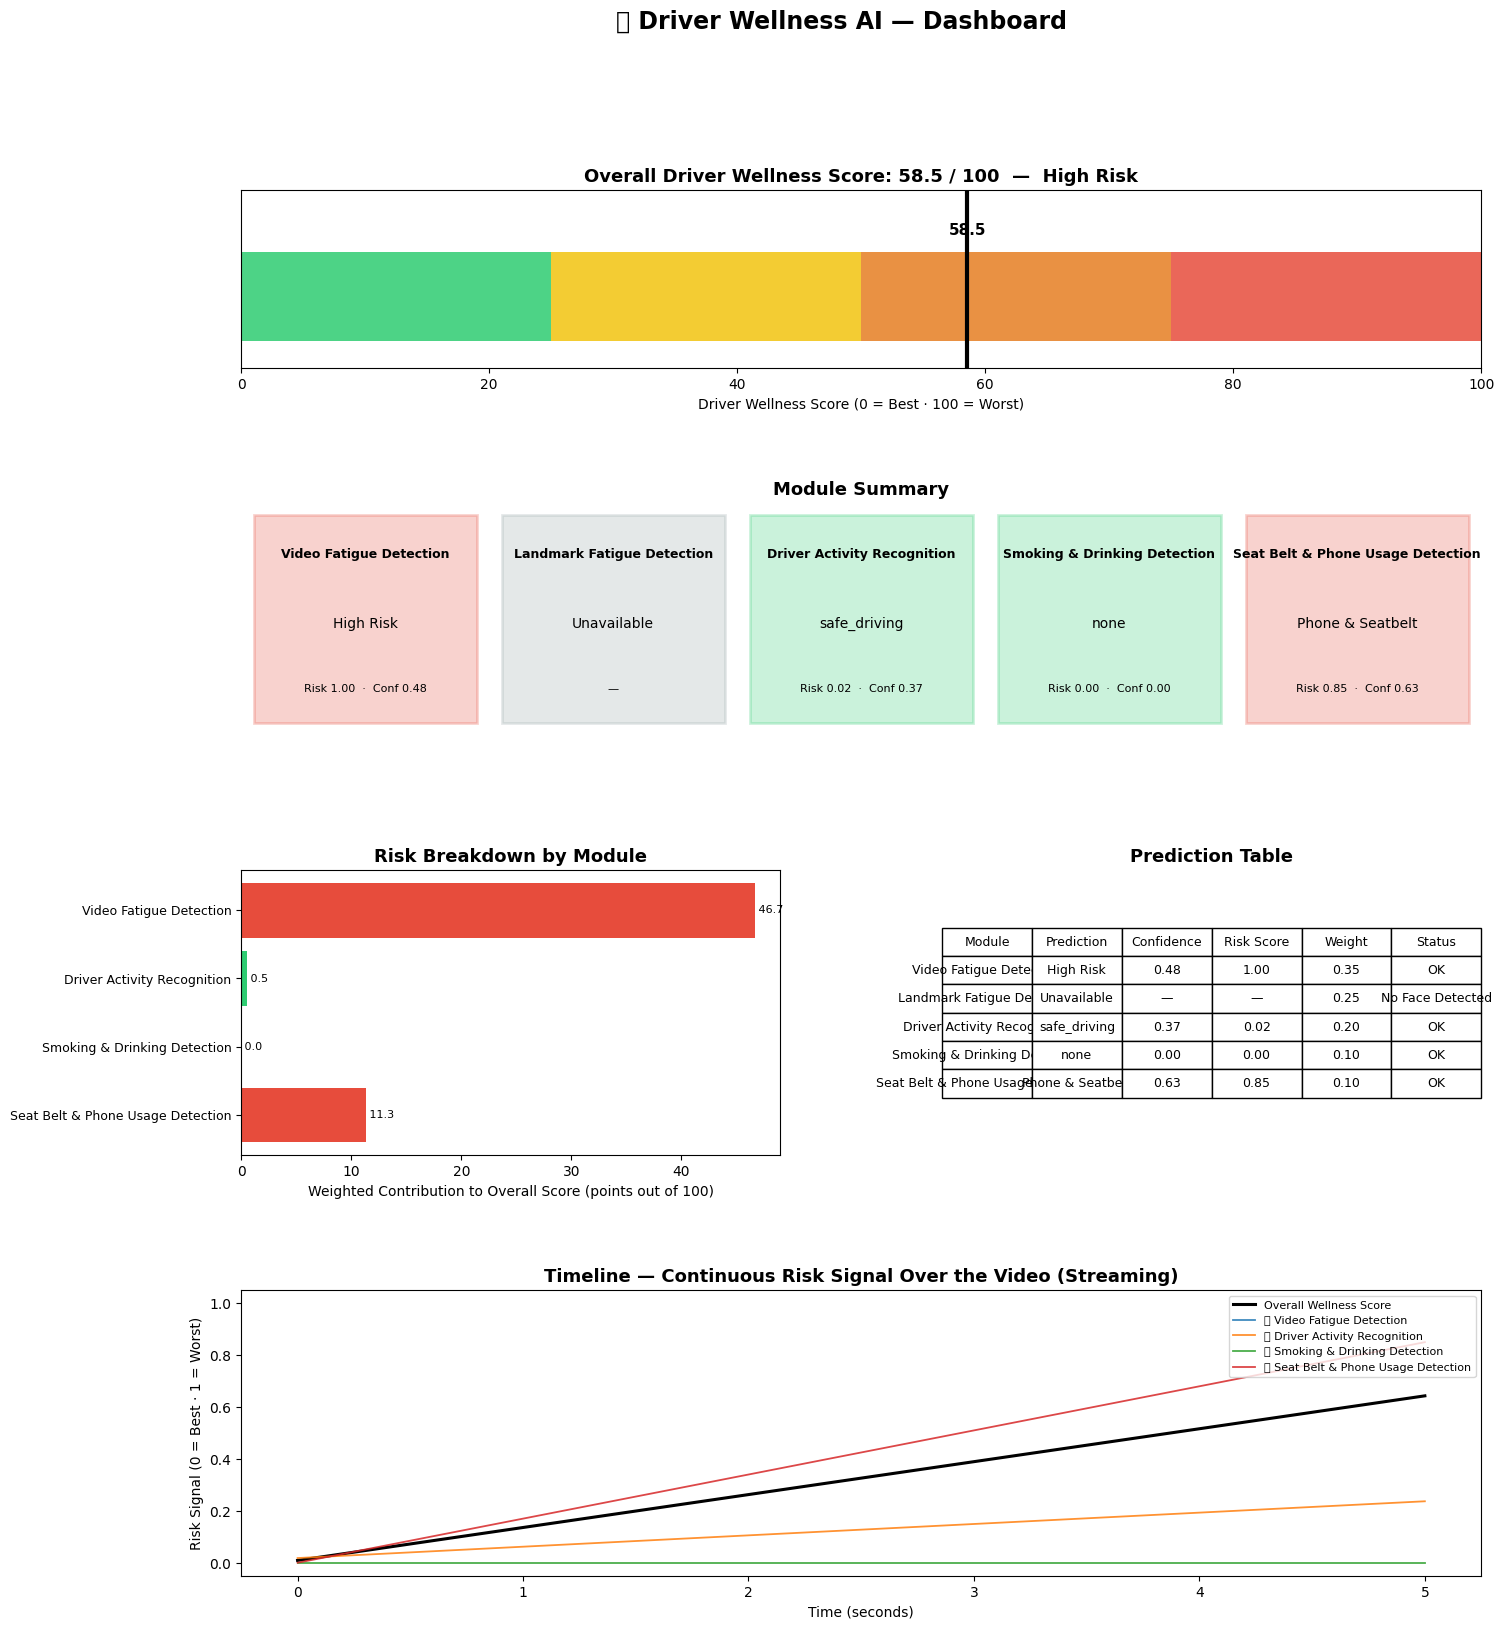


DRIVER WELLNESS SCORE (streaming final state)
Overall Score : 58.5 / 100
Risk Level    : High Risk
Modules ready : ['video_fatigue', 'driver_activity', 'smoking', 'seatbelt']
Warming up    : []


In [44]:
import time
from PIL import Image  # ensure PIL.Image is not shadowed by IPython.display.Image

print("=" * 80)
print("Driver Wellness AI — STREAMING Sliding-Window Simulation")
print("=" * 80)
print(f"Video : {video_path}")
print(f"Live display : {ENABLE_LIVE_DISPLAY}  |  Segment summaries every {SEGMENT_SUMMARY_SEC}s")

# Sync adapter checkpoint paths with the user-provided MODEL_ROOT
for module_key, module_info in MODEL_REGISTRY.items():
    checkpoint_name = Path(module_info["checkpoint"]).name
    resolved_path = MODEL_ROOT / checkpoint_name
    module_info["checkpoint"] = str(resolved_path)

    adapter = module_manager.get_adapter(module_key)
    adapter.checkpoint_path = resolved_path
    adapter.model = None

print(f"MODEL_ROOT : {MODEL_ROOT}")
print("Reloading models from corrected checkpoint paths...")
module_manager.load_all()

# Re-register the seatbelt adapter to ensure it has the latest process_frame method
module_manager.register_adapter(
    "seatbelt", SeatBeltPhoneDetectionAdapter(MODEL_REGISTRY["seatbelt"]["checkpoint"], device=DEVICE)
)

streaming_orchestrator.manager = module_manager

streaming_result = streaming_orchestrator.run_recorded_video(video_path)

prediction_results = streaming_result["prediction_results"]
fusion_result = streaming_result["fusion_result"]

print("\nContinuous fusion produced", len(streaming_result["score_timeline"]), "score updates")
print(f"Segment summaries : {len(streaming_result['segment_summaries'])}")
print(f"Peak RAM (MB)     : {streaming_result['memory']['peak_ram_mb']}")

render_dashboard(prediction_results, fusion_result, streaming_result=streaming_result)

print("\n" + "=" * 80)
print("DRIVER WELLNESS SCORE (streaming final state)")
print("=" * 80)
print(f"Overall Score : {fusion_result['overall_score']:.1f} / 100")
print(f"Risk Level    : {fusion_result['risk_level']}")
print(f"Modules ready : {fusion_result.get('modules_ready', [])}")
print(f"Warming up    : {fusion_result.get('modules_warming_up', [])}")


## 15b. Legacy Batch Mode (short videos only)


Driver Wellness AI — LEGACY Batch Pipeline
Video duration : 0.1 minutes (205 frames @ 24.0 fps)
Video is short enough for legacy batch mode. Running...



ERROR:LandmarkFatigueAdapter:Landmark Fatigue Detection failed: [Landmark Fatigue Detection] Face not detected in one or more frames of every window.
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


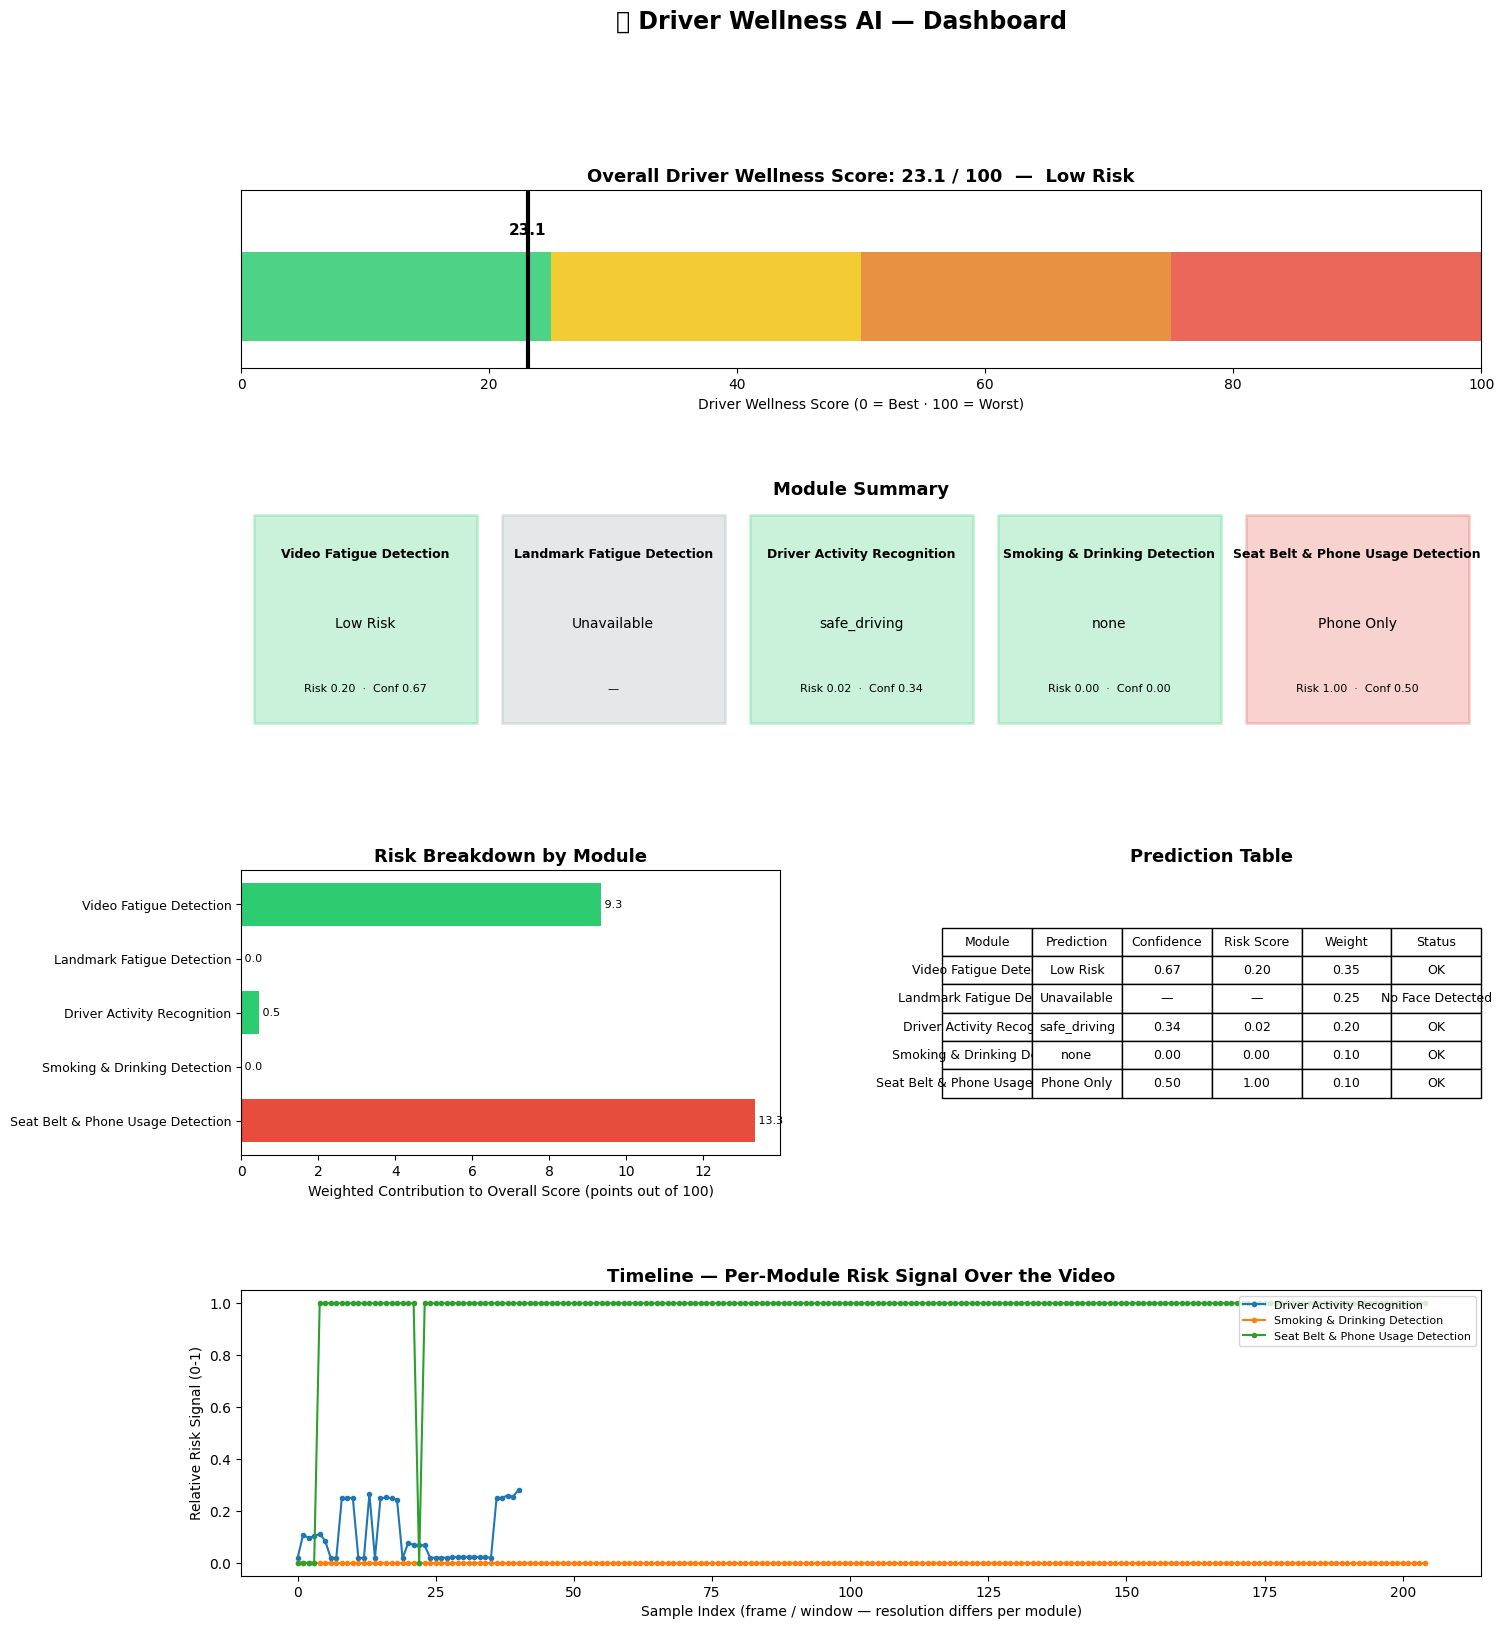

In [45]:
# ==========================================================
# LEGACY BATCH MODE (short videos / backward compatibility)
# Each module re-opens and decodes the full video independently.
# NOT recommended for 10-minute videos on Colab — will likely OOM.
# ==========================================================
import cv2

print("=" * 80)
print("Driver Wellness AI — LEGACY Batch Pipeline")
print("=" * 80)

cap = cv2.VideoCapture(str(video_path))
if not cap.isOpened():
    raise VideoDecodeError(f"Cannot open video: {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
cap.release()

duration_min = (total_frames / fps) / 60.0 if total_frames > 0 else 0.0
print(f"Video duration : {duration_min:.1f} minutes ({total_frames:,} frames @ {fps:.1f} fps)")

if duration_min > LEGACY_MAX_VIDEO_MINUTES:
    raise RuntimeError(
        f"\nLegacy batch mode is blocked for videos longer than {LEGACY_MAX_VIDEO_MINUTES} minutes.\n"
        f"Your video is {duration_min:.1f} minutes — it loads the entire video into RAM up to 5 times "
        f"(once per module), which causes Colab to run out of memory.\n\n"
        f"✅ Use Section 15 'Streaming Sliding-Window Simulation' instead.\n"
        f"   It decodes the video once and keeps memory bounded."
    )

print("Video is short enough for legacy batch mode. Running...\n")

context = InferenceContext(video_path=video_path, device=DEVICE)
prediction_results_batch = module_manager.run_all(context)
fusion_result_batch = risk_fusion_engine.fuse(prediction_results_batch)
render_dashboard(prediction_results_batch, fusion_result_batch)

## Live Camera Simulation


Starting SIMULATED live stream from recorded video (Colab-compatible)...
Source : /content/drive/MyDrive/videos/5834193-uhd_2160_3840_24fps (1).mp4


Streaming inference:   0%|          | 0/205 [00:00<?, ?frame/s]


Final fusion result:
{'overall_score': 58.54, 'risk_level': 'High Risk', 'contributions': [{'module': 'Video Fatigue Detection', 'prediction': 'High Risk', 'confidence': 0.5424955487251282, 'risk_score': 1.0, 'weight': 0.35, 'available': True, 'weighted_contribution': 46.67}, {'module': 'Driver Activity Recognition', 'prediction': 'safe_driving', 'confidence': 0.40487679839134216, 'risk_score': 0.02024383991956711, 'weight': 0.2, 'available': True, 'weighted_contribution': 0.54}, {'module': 'Smoking & Drinking Detection', 'prediction': 'none', 'confidence': 0.0, 'risk_score': 0.0, 'weight': 0.1, 'available': True, 'weighted_contribution': 0.0}, {'module': 'Seat Belt & Phone Usage Detection', 'prediction': 'Phone & Seatbelt', 'confidence': 0.6301983594894409, 'risk_score': 0.85, 'weight': 0.1, 'available': True, 'weighted_contribution': 11.33}], 'module_status': {'video_fatigue': 'READY', 'landmark_fatigue': 'UNAVAILABLE', 'driver_activity': 'READY', 'smoking': 'READY', 'seatbelt': 'RE

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127909 (\N{MOVIE CAMERA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128664 (\N{ONCOMING AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128684 (\N{SMOKING SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128241 (\N{MOBILE PHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


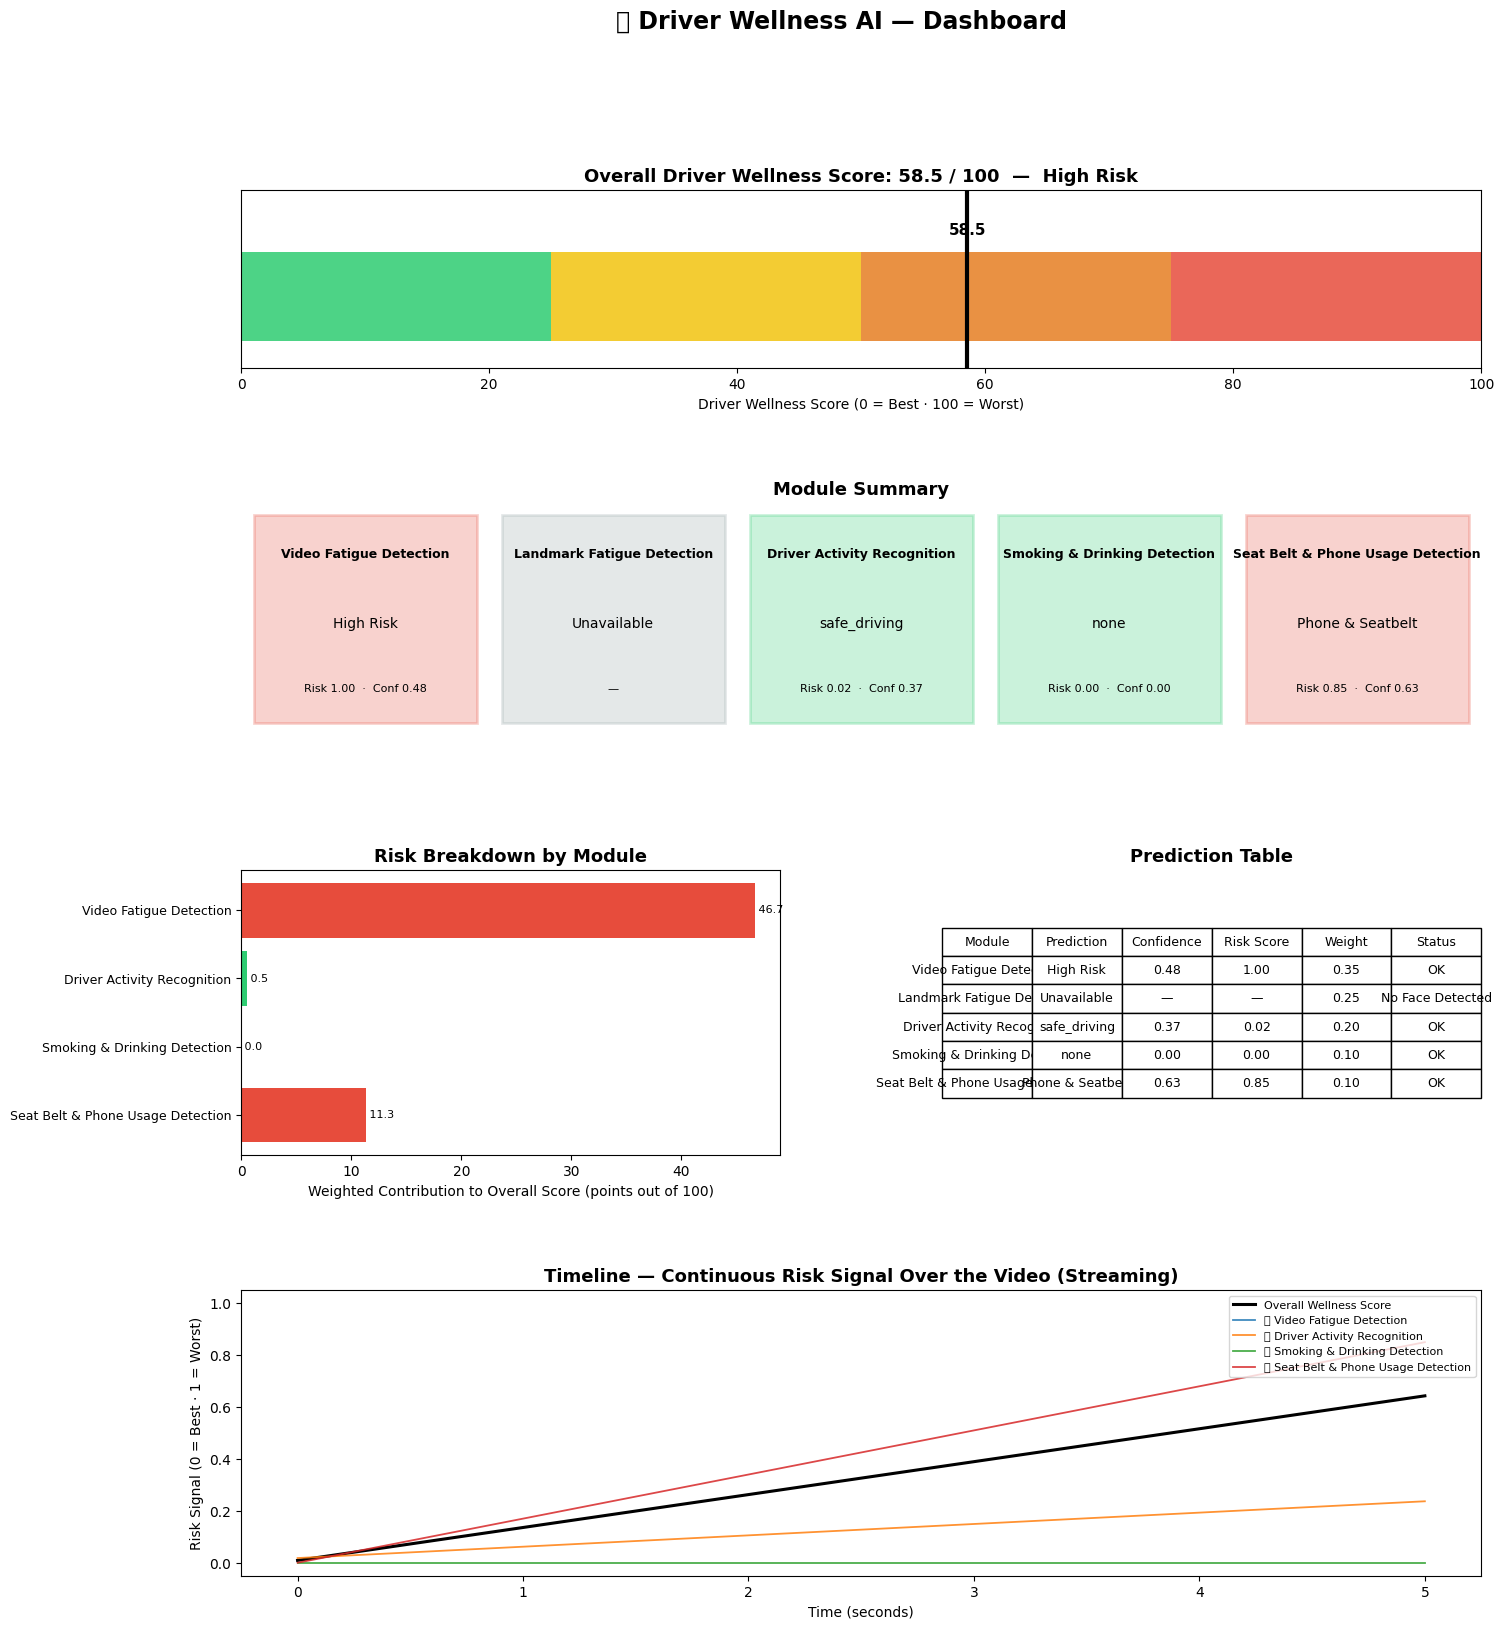

In [46]:
# ==========================================================
# Live Camera Simulation (optional)
# ==========================================================
# Google Colab has NO webcam access — use LIVE_SIMULATED_VIDEO = True on Colab.
# Real webcam (source=0) works only on a local machine with a connected camera.

LIVE_USE_WEBCAM = False       # True → local laptop webcam only
LIVE_SIMULATED_VIDEO = True   # True → replay video_path frame-by-frame (Colab-safe)
LIVE_MAX_FRAMES = 900         # limit frames (~30s at 30fps); None = full video

import cv2

# Sync model paths (same as Section 15)
for module_key, module_info in MODEL_REGISTRY.items():
    checkpoint_name = Path(module_info["checkpoint"]).name
    resolved_path = MODEL_ROOT / checkpoint_name
    module_info["checkpoint"] = str(resolved_path)
    adapter = module_manager.get_adapter(module_key)
    adapter.checkpoint_path = resolved_path
    adapter.model = None
module_manager.load_all()
streaming_orchestrator.manager = module_manager

if LIVE_USE_WEBCAM:
    test_cap = cv2.VideoCapture(0)
    if not test_cap.isOpened():
        test_cap.release()
        raise VideoDecodeError(
            "Webcam not available.\n"
            "• On Google Colab: set LIVE_USE_WEBCAM = False and LIVE_SIMULATED_VIDEO = True\n"
            "• On local machine: check camera permissions and that no other app is using the camera"
        )
    test_cap.release()
    print("Starting LIVE webcam simulation (local camera)...")
    live_result = streaming_orchestrator.run_webcam(source=0, max_frames=LIVE_MAX_FRAMES)

elif LIVE_SIMULATED_VIDEO:
    print("Starting SIMULATED live stream from recorded video (Colab-compatible)...")
    print(f"Source : {video_path}")
    live_result = streaming_orchestrator.run_recorded_video(
        video_path,
        max_frames=LIVE_MAX_FRAMES,
    )

else:
    raise ValueError("Enable either LIVE_USE_WEBCAM or LIVE_SIMULATED_VIDEO.")

print("\nFinal fusion result:")
print(live_result["fusion_result"])

render_dashboard(
    live_result["prediction_results"],
    live_result["fusion_result"],
    streaming_result=live_result,
)

## 16. Real-Time Smoking & Drinking Stream (live, no download)

Instead of writing an annotated `*.mp4` and handing you a download link, this plays the video
**live inside the notebook**: each frame is decoded, run through the YOLOv8n detector, passed
through the **temporal-consistency layer**, and displayed immediately — so **bounding boxes appear
in real time, only for smoking / drinking, and only once the action is temporally confirmed**.

- `source=None` streams the uploaded `video_path`.
- `source="/content/other.mp4"` streams a specific file.
- `source=0` streams a **webcam** (works in local Jupyter; in Colab a plain `cv2` webcam is not
  available, so use a file there).

It reuses the already-loaded smoking model from `module_manager` when present (falling back to
loading the checkpoint directly), so run it any time after the adapters are registered.


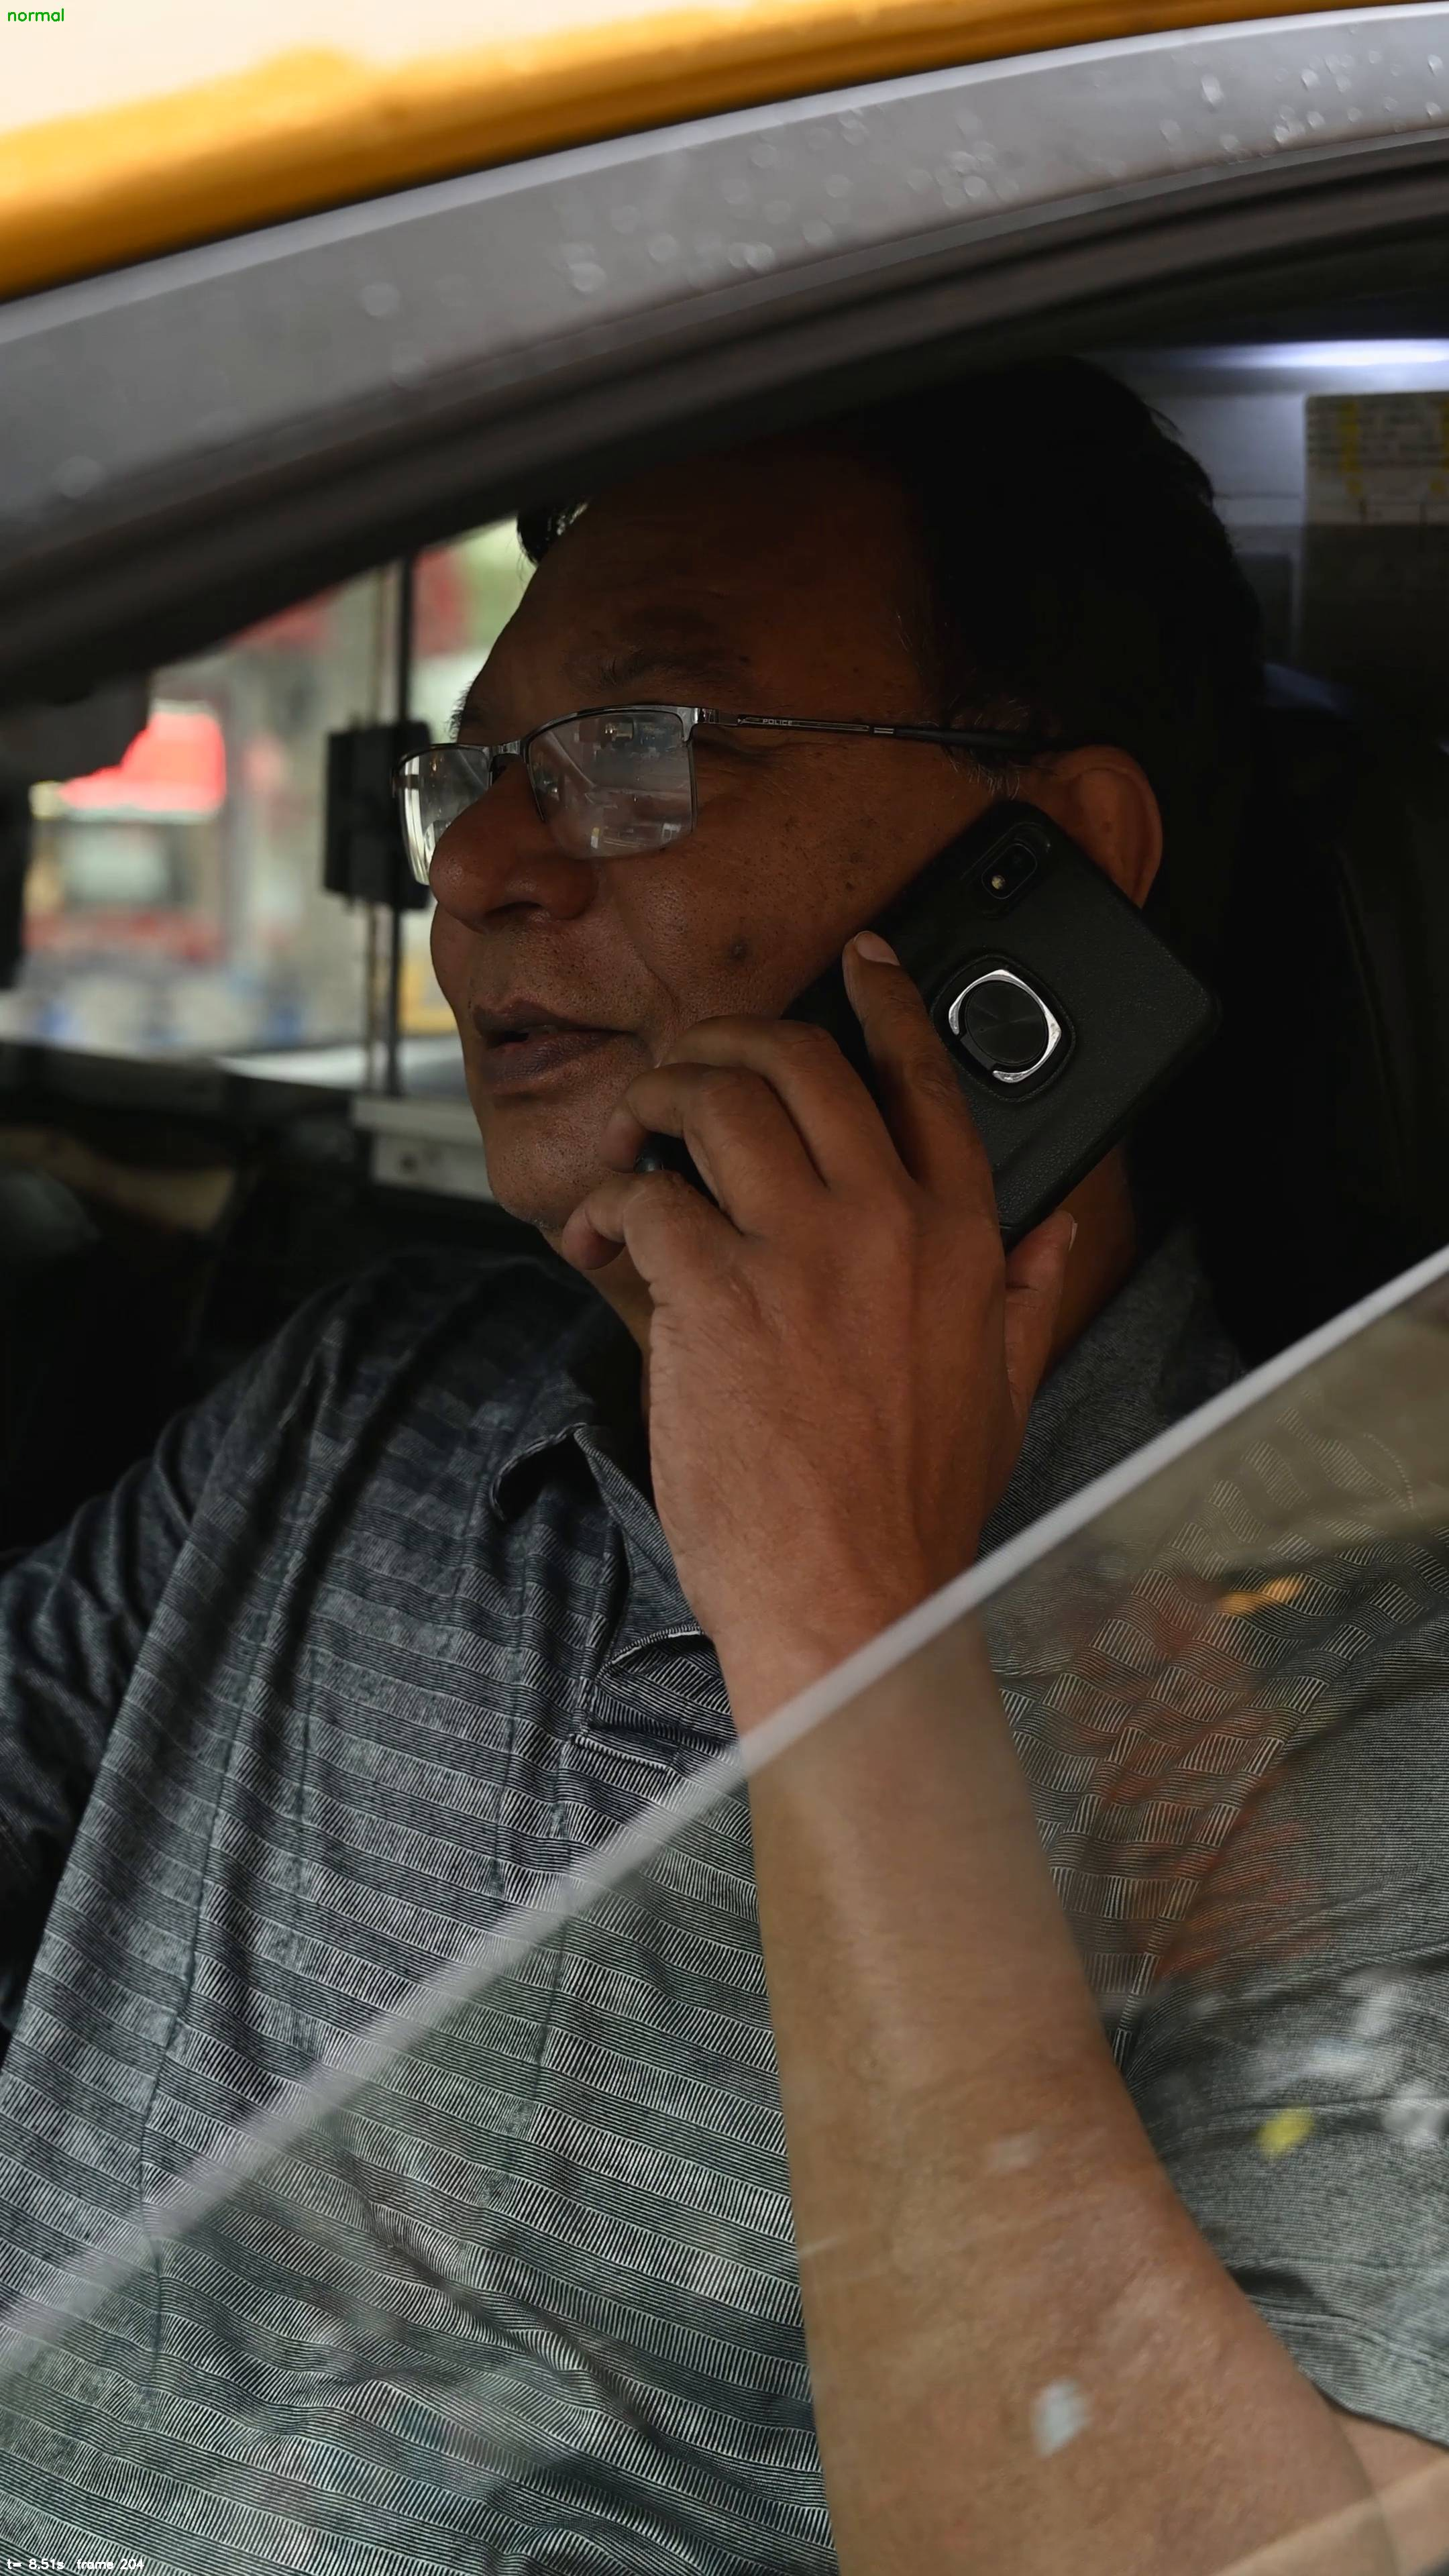


Done. Streamed 205 frame(s). Confirmed events:
  (none - all detections were momentary and got filtered out)


In [47]:
# ==========================================================
# Real-Time Smoking & Drinking Stream — live inline, no file, no download
# ==========================================================
import time
from IPython.display import display, Image, clear_output


def stream_smoking_drinking(source=None, max_frames=None, jpeg_quality=70,
                            pace_realtime=True, stride=1):
    """
    Stream a video (or webcam) inline and draw smoking/drinking boxes in real
    time, using the SAME temporal-consistency layer as SmokingAdapter. Nothing
    is written to disk and nothing is downloaded — frames render live as they
    are processed, and a box only appears once its class is temporally CONFIRMED.

    Args:
        source: None -> global `video_path`; a path string; or an int webcam index.
        max_frames: stop after this many frames (None = whole video).
        jpeg_quality: 1-100, lower = faster/smaller inline frames.
        pace_realtime: sleep so playback never runs faster than the source fps.
        stride: process 1 of every `stride` frames (>=1) to speed up on CPU.
    """
    # --- resolve the model + temporal params (reuse the loaded adapter if we can) ---
    adapter = None
    try:
        adapter = module_manager.get_adapter("smoking")
        adapter._ensure_loaded()
    except Exception:
        adapter = SmokingAdapter(MODEL_REGISTRY["smoking"]["checkpoint"], device=DEVICE)
        adapter._ensure_loaded()

    model = adapter.model
    imgsz = adapter.imgsz
    conf_threshold = adapter.conf_threshold
    conf_per_class = adapter.conf_per_class
    device_arg = 0 if DEVICE.type == "cuda" else "cpu"

    # --- resolve the source ---
    if source is None:
        source = video_path  # from the Upload cell
    cap = cv2.VideoCapture(source)
    if not cap.isOpened():
        raise VideoDecodeError(f"Cannot open source: {source!r}")

    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    voter, window, on_hits, off_hits = TemporalVoter.from_fps(
        fps, adapter.window_sec, adapter.on_frac, adapter.off_frac)
    frame_period = (stride / fps) if pace_realtime else 0.0

    print(f"Streaming {source!r}  |  fps={fps:.1f}  window={window}f  "
          f"on>={on_hits}  off<={off_hits}  stride={stride}")
    print("Boxes appear only once smoking/drinking is temporally confirmed. "
          "Interrupt the cell to stop.\n")

    enc = [int(cv2.IMWRITE_JPEG_QUALITY), int(jpeg_quality)]
    prev_confirmed, events, frame_idx, shown = set(), [], 0, 0
    t_wall = time.time()
    try:
        while True:
            ok, frame = cap.read()
            if not ok:
                break
            if stride > 1 and (frame_idx % stride != 0):
                frame_idx += 1
                continue

            # raw per-frame detection filtered by per-class conf floor
            res = model.predict(frame, imgsz=imgsz, conf=conf_threshold,
                                device=device_arg, verbose=False)[0]
            raw = []
            if res.boxes is not None:
                for box in res.boxes:
                    cid = int(box.cls.item())
                    names = res.names
                    cname = names.get(cid, str(cid)) if isinstance(names, dict) else str(cid)
                    cf = float(box.conf.item())
                    if cf < conf_per_class.get(cname, conf_threshold):
                        continue
                    xyxy = [float(v) for v in box.xyxy.squeeze(0).tolist()]
                    raw.append((cname, cf, xyxy))

            confirmed = voter.update({r[0] for r in raw})
            for c in confirmed - prev_confirmed:
                events.append((frame_idx, frame_idx / fps, c, "START"))
            for c in prev_confirmed - confirmed:
                events.append((frame_idx, frame_idx / fps, c, "END"))
            prev_confirmed = confirmed

            annotated = _draw_confirmed(frame, raw, confirmed)
            cv2.putText(annotated, f"t={frame_idx / fps:5.2f}s  frame {frame_idx}",
                        (10, annotated.shape[0] - 12), cv2.FONT_HERSHEY_SIMPLEX,
                        0.6, (255, 255, 255), 2)

            ok_enc, buf = cv2.imencode(".jpg", annotated, enc)
            if ok_enc:
                clear_output(wait=True)
                display(Image(data=buf.tobytes()))
            shown += 1

            if pace_realtime:
                lag = frame_period - (time.time() - t_wall)
                if lag > 0:
                    time.sleep(lag)
                t_wall = time.time()

            frame_idx += 1
            if max_frames is not None and shown >= max_frames:
                break
    except KeyboardInterrupt:
        print("\nStopped by user.")
    finally:
        cap.release()

    print(f"\nDone. Streamed {shown} frame(s). Confirmed events:")
    if not events:
        print("  (none - all detections were momentary and got filtered out)")
    for fi, t, c, kind in events:
        print(f"  frame {fi:4d}  t={t:5.2f}s  {c:9s} {kind}")


# --- Run it on the uploaded video (live, boxes appear as they are confirmed) ---
stream_smoking_drinking(source=None, pace_realtime=True, stride=1)


## Long-Video Validation & Regression Tests

In [48]:
# ==========================================================
# Lightweight validation tests
# ==========================================================
from PIL import Image  # restore PIL.Image (shadowed by IPython.display.Image)

import copy

def _test_temporal_voter_preserved():
    voter = TemporalVoter(window=5, on_hits=3, off_hits=1)
    confirmed = voter.update({"smoking"})
    assert isinstance(confirmed, set)
    print("[PASS] TemporalVoter operational")

def _test_bounded_video_buffer():
    adapter = module_manager.get_adapter("video_fatigue")
    adapter.reset_streaming_state()
    dummy = np.zeros((480, 640, 3), dtype=np.uint8)
    for i in range(40):
        adapter.process_frame(dummy, i, i / 30.0)
    assert len(adapter._stream_buffer) <= VIDEO_FATIGUE_WINDOW
    print(f"[PASS] Video buffer bounded at {len(adapter._stream_buffer)} <= {VIDEO_FATIGUE_WINDOW}")

def _test_bounded_landmark_buffer():
    adapter = module_manager.get_adapter("landmark_fatigue")
    adapter.reset_streaming_state()
    dummy = np.zeros((480, 640, 3), dtype=np.uint8)
    for i in range(80):
        adapter.process_frame(dummy, i, i / 30.0)
    assert len(adapter._stream_feature_buffer) <= LANDMARK_WINDOW_SIZE
    print(f"[PASS] Landmark buffer bounded at {len(adapter._stream_feature_buffer)}")

def _test_continuous_fusion_before_end():
    if "streaming_result" not in globals():
        raise RuntimeError("Run Section 15 (Primary Demo) first — streaming_result is not defined.")
    assert len(streaming_result.get("score_timeline", [])) > 1
    print(f"[PASS] Continuous fusion: {len(streaming_result['score_timeline'])} score updates")

def _test_display_disabled_runs():
    print(f"[PASS] Display toggle configured (ENABLE_LIVE_DISPLAY = {ENABLE_LIVE_DISPLAY})")

_test_temporal_voter_preserved()
_test_bounded_video_buffer()
_test_bounded_landmark_buffer()
_test_continuous_fusion_before_end()
_test_display_disabled_runs()
print("\nAll lightweight validation checks passed.")

[PASS] TemporalVoter operational
[PASS] Video buffer bounded at 16 <= 16
[PASS] Landmark buffer bounded at 45
[PASS] Continuous fusion: 2 score updates
[PASS] Display toggle configured (ENABLE_LIVE_DISPLAY = False)

All lightweight validation checks passed.
